In [1]:
#imports 

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from matplotlib.ticker import LogFormatterSciNotation, MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg


# Corr Gaussian

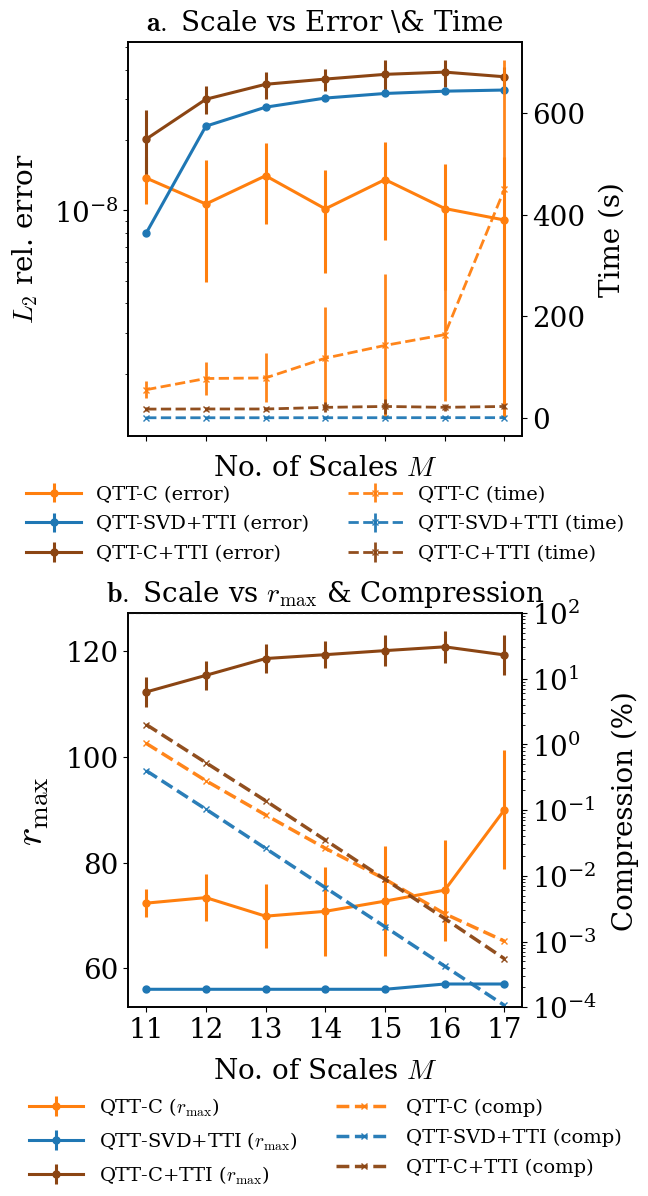

In [2]:
# corr_gaussian_results_formatted_like_wing.py
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

LEGEND_FS = 14

from matplotlib.ticker import (
    MaxNLocator, LogFormatterSciNotation,
    LogLocator, LogFormatterMathtext, FuncFormatter
)

# ── Style: match your reference (fonts/line widths)
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 11,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})
plt.rcParams["axes.grid"] = False

# ── Load & aggregate
CG_PATH = "./data/masks/corr_gaussian_results_2.jsonl"
records = []
with open(CG_PATH, "r") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(["method", "scale"])
      .agg(
          error_mean=("error", "mean"),
          error_std =("error", "std"),
          time_mean =("time", "mean"),
          time_std  =("time", "std"),
          rmax_mean =("rmax", "mean"),
          rmax_std  =("rmax", "std"),
          erank_mean=("erank", "mean"),
          erank_std =("erank", "std"),
      )
      .reset_index()
)

# ── Pretty names + fixed colors (as requested)
label_map = {
    "cross":     r"QTT-C",
    "cross_int": r"QTT-C+TTI",
    "svd_int":   r"QTT-SVD+TTI",
}
color_map = {
    "cross":     "tab:orange",
    "svd_int":   "tab:blue",
    "cross_int": "saddlebrown",  # brown
}

# Keep a stable method order (cross, svd_int, cross_int, then anything else)
methods_raw = list(stats["method"].unique())
preferred_order = ["cross", "svd_int", "cross_int"]
methods = [m for m in preferred_order if m in methods_raw] + [m for m in methods_raw if m not in preferred_order]

def pretty(m):  # fallback if an unexpected method appears
    return label_map.get(m, m)

def mcolor(m):
    return color_map.get(m, "tab:gray")

# ── Figure (2×1), share x — same layout as the wing version
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(9.2, 14.2), sharex=True)
ax2 = ax1.twinx()   # time axis
ax4 = ax3.twinx()   # compression axis

# ── Choose dimension for compression formula:
# If your field is 2D (mask image), use DIM=2; if 3D volume, use DIM=3.
DIM = 2

# --- (a) Error (log) & Time ---
for method in methods:
    d = stats[stats["method"] == method].sort_values("scale")
    c = mcolor(method)
    name = pretty(method)

    # Error (solid)
    ax1.errorbar(
        d["scale"], d["error_mean"], yerr=d["error_std"],
        marker="o", linestyle="-", color=c,
        label=rf"{name} (error)", capsize=0, linewidth=2.2, markersize=5
    )
    # Time (dashed)
    ax2.errorbar(
        d["scale"], d["time_mean"], yerr=d["time_std"],
        marker="x", linestyle="--", color=c, alpha=0.95,
        label=rf"{name} (time)", capsize=0, linewidth=2.0, markersize=5
    )

ax1.set_yscale("log")
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_xlabel(r"No. of Scales $M$", labelpad=10)

ax1.set_ylabel(r"$L_2$ rel. error", labelpad=10)
ax2.set_ylabel(r"Time (s)", labelpad=10)
ax1.set_title(r"$\mathbf{a.}$ Scale vs Error \& Time", pad=8)

# Make panel more square (just like the wing figure)
try:
    ax1.set_box_aspect(1.0)
except Exception:
    pass

# Legend BELOW the top plot (combine lines from both axes)
LEG_Y  = -0.2
N_COLS = 2
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc="upper center", bbox_to_anchor=(0.5, LEG_Y),
    frameon=False, fontsize=LEGEND_FS , handlelength=2.8,
    labelspacing=0.6, borderpad=-2, ncol=N_COLS
)

# --- (b) r_max (left) & Compression (right, log) ---

# First pass: compute global robust log-limits for compression so all methods share same scale
comp_lows, comp_highs = [], []
for method in methods:
    d = stats[stats["method"] == method].sort_values("scale")
    M = d["scale"].to_numpy(dtype=float)

    r  = d["erank_mean"].to_numpy(dtype=float)
    rs = d["erank_std"].to_numpy(dtype=float)

    comp_ratio     = (DIM * M * r**2)  / (2.0 ** (DIM * M))
    comp_ratio_std = (DIM * M * rs**2) / (2.0 ** (DIM * M))

    comp_lo = np.clip((comp_ratio - comp_ratio_std) * 100.0, 1e-12, None)
    comp_hi = (comp_ratio + comp_ratio_std) * 100.0

    comp_lows.append(float(np.nanmin(comp_lo)))
    comp_highs.append(float(np.nanmax(comp_hi)))

# robust log limits (with sensible anchors)
cmin = float(min(comp_lows + [1e-4]))
cmax = float(max(comp_highs + [100.0]))
lo_dec = 10 ** np.floor(np.log10(cmin))
hi_dec = 10 ** np.ceil(np.log10(cmax))

ax4.set_yscale("log")
ax4.set_ylim(lo_dec, hi_dec)
ax4.yaxis.set_major_locator(LogLocator(base=10))
ax4.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
ax4.yaxis.set_minor_formatter(FuncFormatter(lambda *_: ""))

# 100% reference line
ax4.axhline(y=100, color="gray", linestyle="--", alpha=0.5, linewidth=1)

# Second pass: plot rmax + compression
for method in methods:
    d = stats[stats["method"] == method].sort_values("scale")
    M = d["scale"].to_numpy(dtype=float)
    c = mcolor(method)
    name = pretty(method)

    # r_max (left)
    ax3.errorbar(
        M, d["rmax_mean"], yerr=d["rmax_std"],
        marker="o", linestyle="-", color=c,
        label=rf"{name} ($r_{{\max}}$)", capsize=0, linewidth=2.2, markersize=5
    )

    # compression (right) from erank
    r  = d["erank_mean"].to_numpy(dtype=float)
    rs = d["erank_std"].to_numpy(dtype=float)

    comp_ratio     = (DIM * M * r**2)  / (2.0 ** (DIM * M))
    comp_ratio_std = (DIM * M * rs**2) / (2.0 ** (DIM * M))

    comp    = comp_ratio * 100.0
    comp_lo = np.clip((comp_ratio - comp_ratio_std) * 100.0, 1e-12, None)
    comp_hi = (comp_ratio + comp_ratio_std) * 100.0

    ax4.plot(M, comp, "--x", color=c, alpha=0.95, ms=5, label=rf"{name} (comp)")
    ax4.fill_between(M, comp_lo, comp_hi, color=c, alpha=0.12, linewidth=0)

ax3.set_xlabel(r"No. of Scales $M$", labelpad=10)
ax3.set_ylabel(r"$r_{\max}$", labelpad=10,size=28)
ax4.set_ylabel(r"Compression (%)", labelpad=10)
ax3.set_title(r"$\mathbf{b.}$ Scale vs $r_{\max}$ & Compression", pad=8)
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

# Make panel more square
try:
    ax3.set_box_aspect(1.0)
except Exception:
    pass

# Legend BELOW the bottom plot (combine both axes)
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(
    lines3 + lines4, labels3 + labels4,
    loc="upper center", bbox_to_anchor=(0.5, LEG_Y),
    frameon=False, fontsize=LEGEND_FS , handlelength=2.8,
    labelspacing=0.6, borderpad=0, ncol=N_COLS
)

# Thicken spines
for ax in (ax1, ax2, ax3, ax4):
    for s in ax.spines.values():
        s.set_linewidth(1.2)

# Extra bottom margin so legends have room underneath each subplot
fig.subplots_adjust(left=0.12, right=0.98, top=0.92, bottom=0.24, hspace=0.45)

# Save
out_dir = "./plots"
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, "corr_gaussian_results.pdf"),
            format="pdf", bbox_inches="tight", facecolor="white")
fig.savefig(os.path.join(out_dir, "corr_gaussian_results.png"),
            dpi=200, bbox_inches="tight", facecolor="white")

plt.show()


# Masks

## 1D funciton

In [4]:
# 1) LaTeX style: serif font + Computer Modern mathtext
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Load & aggregate
#df = pd.read_csv('./data/mask_results.csv')
records = []
with open('./data/masks/1d_funciton.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:      # skip empty or whitespace-only lines
            continue
        records.append(json.loads(line))

df = pd.DataFrame(records)
df.to_csv('1d_records.csv',index=False)

/tmp/ipykernel_2528215/1559022564.py:119: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: weighted_error_stats(g))


Saved ./plots/1d_function.[pdf|png]


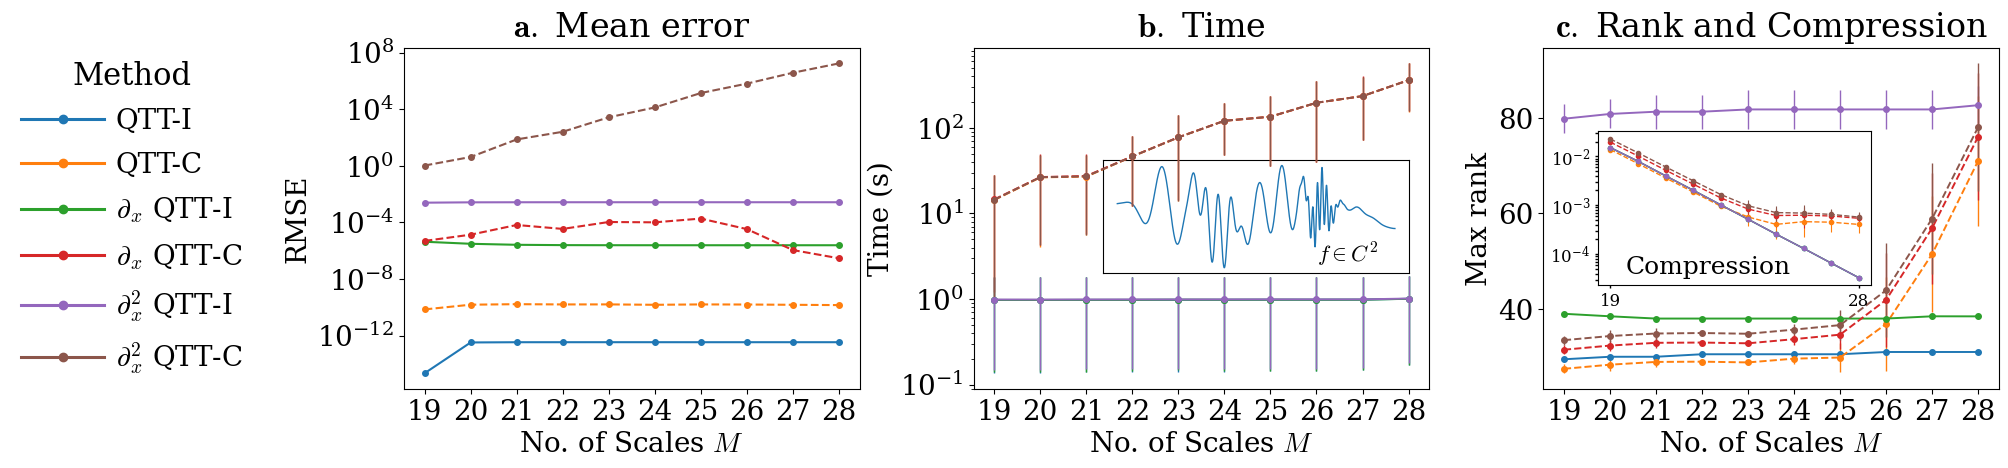

In [5]:
# make_plots_with_outside_legend.py
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterMathtext
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────────────────
# Style (match your formatted version; no grid lines)
# ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.grid": False,
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 11,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

# ─────────────────────────────────────────────────────────
# Load data
# ─────────────────────────────────────────────────────────
CSV_PATH = "1d_records.csv"
df = pd.read_csv(CSV_PATH)

required = {"method", "scale", "error", "serror"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}. "
                     f"Found: {list(df.columns)}")

for c in ["scale", "error", "serror"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=list(required))

have_time = "time" in df.columns
have_rmax = "rmax" in df.columns
have_erank = "erank" in df.columns

# ─────────────────────────────────────────────────────────
# Method labels: normalize, order, pretty
# ─────────────────────────────────────────────────────────
base_map = {
    "d TTTI": "d QTT-I",
    "dd TTI": "dd QTT-I",
    "d cross": "d QTT-C",
    "dd cross": "dd QTT-C",
    "TTI": "QTT-I",
    "cross": "QTT-C",
    "cross_int": "QTT-C + Int",
    "qtt-tucker": "QTT-T + Int",
    "qtt_tucker": "QTT-T + Int",
    "svd_int": "QTT-SVD + Int",
}
df["method_base"] = df["method"].map(base_map).fillna(df["method"])

order_base = [
    "QTT-I", "QTT-C",
    "d QTT-I", "d QTT-C",
    "dd QTT-I", "dd QTT-C",
]
extras = [m for m in df["method_base"].unique() if m not in order_base]
order_base_final = order_base + extras
df["method_base"] = pd.Categorical(df["method_base"],
                                   categories=order_base_final,
                                   ordered=True)

def pretty_label(txt: str) -> str:
    t = str(txt).strip()
    if t.startswith("dd "):
        return r"$\partial_{x}^2$ " + t[3:]
    if t.startswith("d "):
        return r"$\partial_{x}$ " + t[2:]
    return t

df["method_pretty"] = df["method_base"].astype(str).map(pretty_label)
order_pretty = [pretty_label(x) for x in order_base_final]
df["method_pretty"] = pd.Categorical(df["method_pretty"],
                                     categories=order_pretty,
                                     ordered=True)

methods_in_order = [m for m in df["method_pretty"].cat.categories
                    if m in df["method_pretty"].unique()]

# ─────────────────────────────────────────────────────────
# Aggregations
# ─────────────────────────────────────────────────────────
def simple_stats(col: str) -> pd.DataFrame:
    if col not in df.columns:
        return pd.DataFrame()
    out = (
        df.groupby(["method", "method_base", "method_pretty", "scale"],
                   observed=True, sort=False)[col]
          .agg(["mean", "std"])
          .reset_index()
          .rename(columns={"mean": f"{col}_mean", "std": f"{col}_std"})
    )
    out = (out.replace([np.inf, -np.inf], np.nan)
              .dropna(subset=[f"{col}_mean"])
              .sort_values(["method_pretty", "scale"]))
    return out

def weighted_error_stats(group: pd.DataFrame) -> pd.Series:
    w = 1.0 / (group["serror"].values ** 2)
    x = group["error"].values
    wsum = w.sum()
    mu = np.sum(w * x) / wsum
    se = np.sqrt(1.0 / wsum)
    return pd.Series({"n": len(group), "error_wmean": mu, "error_wse": se})

# (a) Weighted error ± SE
err_stats_w = (
    df.groupby(["method", "method_base", "method_pretty", "scale"],
               observed=True, sort=False)
      .apply(lambda g: weighted_error_stats(g))
      .reset_index()
)
err_stats_w = (err_stats_w.replace([np.inf, -np.inf], np.nan)
                         .dropna(subset=["error_wmean", "error_wse"])
                         .sort_values(["method_pretty", "scale"]))

# (b) Time, (c) Max rank, and inset Compression (simple mean ± SD)
time_stats  = simple_stats("time")  if have_time  else pd.DataFrame()
rmax_stats  = simple_stats("rmax")  if have_rmax  else pd.DataFrame()
erank_stats = simple_stats("erank") if have_erank else pd.DataFrame()

# Colors
palette = plt.cm.tab10.colors
color_map = {m: palette[i % len(palette)] for i, m in enumerate(methods_in_order)}

def is_cross(base_name: str, raw_name: str) -> bool:
    t = (str(base_name) or "").lower() + " " + (str(raw_name) or "").lower()
    return ("cross" in t) or ("qtt-c" in t)

# ─────────────────────────────────────────────────────────
# f_h3 inset (NumPy version) — unchanged placement later
# ─────────────────────────────────────────────────────────
def _gauss_np(x, c, s): return np.exp(-0.5*((x - c)/s)**2)
def _chirp_np(x, f0, f1):
    phase = 2*np.pi*(f0*x + 0.5*(f1 - f0)*x**2)
    return np.sin(phase)

def f_h3_np(x, eps=1e-12, amp=1.0):
    base = (0.28*np.sin(16*np.pi*x) * _gauss_np(x, 0.20, 0.07)
          + 0.24*np.cos(44*np.pi*x) * _gauss_np(x, 0.36, 0.05)
          + 0.20*_chirp_np(x, 5, 18) * _gauss_np(x, 0.58, 0.12)
          + 0.18*np.sin(120*np.pi*x)* _gauss_np(x, 0.73, 0.03))
    bg = (0.07*np.sin(2*np.pi*1.8*x + 0.2)
        + 0.05*np.cos(2*np.pi*3.3*x + 0.9))
    def c2_bump(x, a, s, w=1.0):
        return w*np.maximum(x - a, 0.0)**3 * _gauss_np(x, a, s)
    kinks = (c2_bump(x, 0.22, 0.030,  +0.8)
           + c2_bump(x, 0.37, 0.025,  -0.6)
           + c2_bump(x, 0.61, 0.035,  +0.7)
           + c2_bump(x, 0.82, 0.022,  -0.5))
    pads = (-0.6*np.maximum(0.28 - x, 0.0)**3 * _gauss_np(x, 0.28, 0.030)
            +0.5*np.maximum(0.42 - x, 0.0)**3 * _gauss_np(x, 0.42, 0.028)
            -0.5*np.maximum(0.68 - x, 0.0)**3 * _gauss_np(x, 0.68, 0.030)
            +0.4*np.maximum(0.88 - x, 0.0)**3 * _gauss_np(x, 0.88, 0.022))
    f0 = base + bg + kinks + pads
    return amp*np.tanh(f0/2.5)

# ─────────────────────────────────────────────────────────
# Figure: 1×3 panels
# ─────────────────────────────────────────────────────────
fig, (ax_err, ax_time, ax_rmax) = plt.subplots(1, 3, figsize=(22, 4.8))

fig.subplots_adjust(
    left=0.30,    # more margin for the outside legend
    right=0.985,
    bottom=0.17,
    top=0.88,
    wspace=2.5,  # <-- increase subplot horizontal gap
    hspace=0.22   # (useful if you ever stack rows)
)

# (a) Error (weighted mean ± SE), log-y — NO legend here (we'll add outside)
for m in methods_in_order:
    g = err_stats_w.loc[err_stats_w["method_pretty"] == m].sort_values("scale")
    if g.empty:
        continue
    base = g["method_base"].iloc[0]; raw = g["method"].iloc[0]
    ls = "--" if is_cross(base, raw) else "-"
    ax_err.errorbar(
        g["scale"], g["error_wmean"], yerr=g["error_wse"],
        marker="o", linestyle=ls, color=color_map[m],
        capsize=0, elinewidth=1.1, linewidth=1.5, markersize=4
    )
ax_err.set_xlabel("No. of Scales $M$")
ax_err.set_ylabel(r"RMSE")
ax_err.set_yscale("log")
ax_err.yaxis.set_major_formatter(LogFormatterMathtext())
ax_err.xaxis.set_major_locator(MaxNLocator(integer=True))
ax_err.set_title(r"$\mathbf{a.}$ Mean error", fontsize=24, pad=8)

# (b) Time (mean ± SD), log-y — REMOVE legend here
if not time_stats.empty:
    for m in methods_in_order:
        g = time_stats.loc[time_stats["method_pretty"] == m].sort_values("scale")
        if g.empty:
            continue
        base = g["method_base"].iloc[0]; raw = g["method"].iloc[0]
        ls = "--" if is_cross(base, raw) else "-"
        ax_time.errorbar(
            g["scale"], g["time_mean"], yerr=g["time_std"],
            marker="o", linestyle=ls, color=color_map[m],
            capsize=0, elinewidth=1.0, linewidth=1.4, markersize=4
        )
ax_time.set_xlabel("No. of Scales $M$")
ax_time.set_ylabel(r"Time (s)")
ax_time.set_yscale("log")
ax_time.yaxis.set_major_formatter(LogFormatterMathtext())
ax_time.xaxis.set_major_locator(MaxNLocator(integer=True))
ax_time.set_title(r"$\mathbf{b.}$ Time", fontsize=24, pad=8)

# Inset: f_h3(x) — EXACT placement unchanged
xx = np.linspace(0, 1, 2000)
yy = f_h3_np(xx)
iw, ih = 0.67, 0.33
inset2 = ax_time.inset_axes([0.62 - iw/2, 0.34, iw, ih])  # unchanged
# send inset "backwards"
inset2.set_zorder(0)            # inset axes behind
inset2.patch.set_alpha(0.0)     # optional: transparent background
# inset2.patch.set_visible(False)  # alternative: fully remove inset background

# keep main axes on top (usually already is, but you can enforce)
ax_time.set_zorder(2)
inset2.plot(xx, yy, lw=1.0)

# --- remove title, y-label, y-ticks
inset2.set_title("")                      # no title
inset2.set_ylabel("")                     # no y-label
inset2.set_yticks([])                     # no y-ticks
inset2.set_xlabel("")                     # no y-label
inset2.set_xticks([])                     # no y-ticks
inset2.tick_params(axis='y', left=False, labelleft=False)
inset2.tick_params(axis='x', left=False, labelleft=False)


# lower-left corner annotation
inset2.text(0.9, 0.04, r"$f\in C^2$",
            transform=inset2.transAxes,
            fontsize=16, va="bottom", ha="right")


# (c) Max rank (mean ± SD) + inset Compression
if not rmax_stats.empty:
    for m in methods_in_order:
        g = rmax_stats.loc[rmax_stats["method_pretty"] == m].sort_values("scale")
        if g.empty:
            continue
        base = g["method_base"].iloc[0]; raw = g["method"].iloc[0]
        ls = "--" if is_cross(base, raw) else "-"
        ax_rmax.errorbar(
            g["scale"], g["rmax_mean"], yerr=g["rmax_std"],
            marker="o", linestyle=ls, color=color_map[m],
            capsize=0, elinewidth=1.0, linewidth=1.4, markersize=4
        )
ax_rmax.set_xlabel("No. of Scales $M$")
ax_rmax.set_ylabel(r"Max rank")
ax_rmax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax_rmax.set_title(r"$\mathbf{c.}$ Rank and Compression", fontsize=24, pad=8)

if not erank_stats.empty:
    iw3, ih3 = 0.60, 0.45
    inset3 = ax_rmax.inset_axes([0.42 - iw3/2, 0.53 - ih3/2, iw3, ih3])  # unchanged

    # plot compression curves
    for m in methods_in_order:
        g = erank_stats.loc[erank_stats["method_pretty"] == m].sort_values("scale")
        if g.empty:
            continue
        base = g["method_base"].iloc[0]
        raw  = g["method"].iloc[0]
        ls = "--" if is_cross(base, raw) else "-"
        inset3.errorbar(
            g["scale"], g["erank_mean"], yerr=g["erank_std"],
            marker="o", linestyle=ls, color=color_map[m],
            capsize=0, elinewidth=0.8, linewidth=1.0, markersize=3
        )

    # x-ticks: only first/last scale
    scales_sorted = np.sort(df["scale"].unique())
    inset3.set_xticks([scales_sorted[0], scales_sorted[-1]] if len(scales_sorted) > 1
                      else [scales_sorted[0]])

    # (keep your log scaling behavior)
    yvals = erank_stats["erank_mean"].values
    if np.all(yvals > 0):
        from matplotlib.ticker import LogFormatterMathtext
        inset3.set_yscale("log")
        inset3.yaxis.set_major_formatter(LogFormatterMathtext())

    # ---- JUST increase font sizes (no tick-count changes yet)
    inset3.tick_params(axis="both", which="major", labelsize=12)
    inset3.tick_params(axis="both", which="minor", labelsize=12)
    inset3.tick_params(axis="both", which="both", width=1, length=2)

    # annotation
    inset3.text(0.10, 0.04, r"Compression",
                transform=inset3.transAxes,
                fontsize=18, va="bottom", ha="left")




# ─────────────────────────────────────────────────────────
# OUTSIDE-LEFT legend for methods (single legend)
# ─────────────────────────────────────────────────────────
method_handles = [
    Line2D([0], [0],
           linestyle='-', marker='o', color=color_map[m],
           markersize=6, linewidth=2.2, label=m)
    for m in methods_in_order
]

ax_err.legend(
    handles=method_handles,
    title="Method", frameon=False, fontsize=20, title_fontsize=22,
    loc='center right',
    bbox_to_anchor=(-0.30, 0.50),  # move more negative to push farther left
    handlelength=3.0,              # longer legend line
    handletextpad=0.4,             # gap between line and text
    labelspacing=0.6,              # vertical spacing between items
    borderpad=0.4                  # padding inside legend box
)

# Make room on the left for the outside legend, and keep reasonable gaps
fig.subplots_adjust(left=0.26, right=0.985, wspace=0.25, bottom=0.17, top=0.88)

# ─────────────────────────────────────────────────────────
# Save
# ─────────────────────────────────────────────────────────
os.makedirs("./plots", exist_ok=True)
fig.savefig("./plots/1d_function.pdf", bbox_inches="tight", facecolor="white")
fig.savefig("./plots/1d_function.png", dpi=200, bbox_inches="tight", facecolor="white")
print("Saved ./plots/1d_function.[pdf|png]")


## Circle Mask

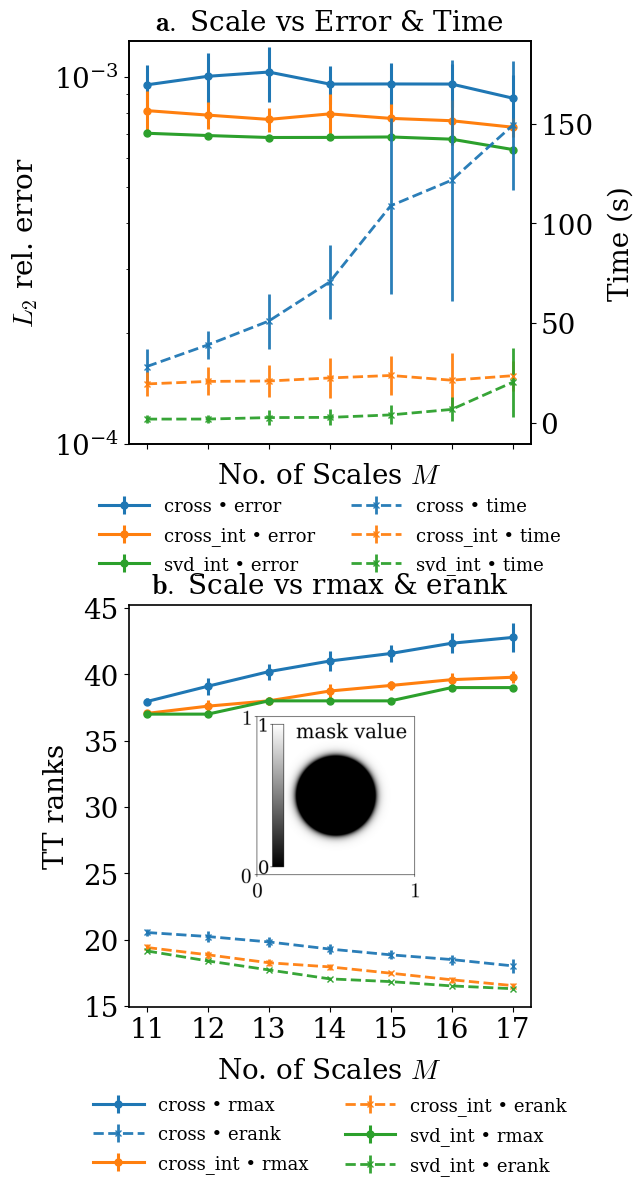

In [40]:
# circle_mask_results_formatted_like_wing.py
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg

# ── Style: match your reference (fonts/line widths)
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 11,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})
plt.rcParams['axes.grid'] = False

# ── Load & aggregate
# Change this path if your file lives elsewhere
CIRCLE_PATH = './data/masks/circle_results_lr.jsonl'
records = []
with open(CIRCLE_PATH, 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(['method', 'scale'])
      .agg(error_mean=('error','mean'),
           error_std =('error','std'),
           time_mean =('time','mean'),
           time_std  =('time','std'),
           rmax_mean =('rmax','mean'),
           rmax_std  =('rmax','std'),
           erank_mean=('erank','mean'),
           erank_std =('erank','std'))
      .reset_index()
)

methods = stats['method'].unique()
colors  = sns.color_palette('tab10', n_colors=len(methods))

# ── Figure (2×1), share x — same size/layout as the wing plot
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(9.2, 14.2), sharex=True)
ax2 = ax1.twinx()

# --- (a) Error (log) & Time ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    # Error (solid)
    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', color=colors[i],
        label=f'{method} • error', capsize=0, linewidth=2.2, markersize=5
    )
    # Time (dashed)
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', color=colors[i], alpha=0.95,
        label=f'{method} • time', capsize=0, linewidth=2.0, markersize=5
    )

ax1.set_yscale('log')
ax1.set_yticks([1e-4, 1e-3])  # keep explicit ticks like the wing version
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_xlabel(r'No. of Scales $M$', labelpad=10)

ax1.set_ylabel(r'$L_2$ rel. error', labelpad=10)
ax2.set_ylabel('Time (s)', labelpad=10)
ax1.set_title(r"$\mathbf{a.}$ Scale vs Error & Time", pad=8)

# Make top panel square-ish
try:
    ax1.set_box_aspect(1.0)
except Exception:
    pass

# Legend BELOW the top plot (combined, centered) — same placement
LEG_Y  = -0.2
N_COLS = 2
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='upper center', bbox_to_anchor=(0.5, LEG_Y),
    frameon=False, fontsize=13, handlelength=2.8,
    labelspacing=0.6, borderpad=-2, ncol=N_COLS
)

# --- (b) rmax & erank ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    ax3.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='o', linestyle='-', color=colors[i],
        label=f'{method} • rmax', capsize=0, linewidth=2.2, markersize=5
    )
    ax3.errorbar(
        d['scale'], d['erank_mean'], yerr=d['erank_std'],
        marker='x', linestyle='--', color=colors[i], alpha=0.95,
        label=f'{method} • erank', capsize=0, linewidth=2.0, markersize=5
    )

ax3.set_xlabel(r'No. of Scales $M$', labelpad=10)
ax3.set_ylabel('TT ranks', labelpad=10)
ax3.set_title(r"$\mathbf{b.}$ Scale vs rmax & erank", pad=8)
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

# Make bottom panel square-ish
try:
    ax3.set_box_aspect(1.0)
except Exception:
    pass

# Legend BELOW the bottom plot (centered) — same placement
lines3, labels3 = ax3.get_legend_handles_labels()
ax3.legend(
    lines3, labels3,
    loc='upper center', bbox_to_anchor=(0.5, LEG_Y),
    frameon=False, fontsize=13, handlelength=2.8,
    labelspacing=0.6, borderpad=0, ncol=N_COLS
)

# ── Inset image centered in the bottom panel (circle)
img_mid = mpimg.imread('./figures/circle.png')
axins = inset_axes(ax3, width="50%", height="50%", loc='center')
axins.imshow(img_mid)
axins.axis('off')
axins.set_zorder(0)
ax3.set_zorder(1)
ax3.patch.set_visible(False)

# Thicken spines
for ax in (ax1, ax2, ax3):
    for s in ax.spines.values():
        s.set_linewidth(1.2)

# Extra bottom margin so legends have room underneath each subplot
fig.subplots_adjust(left=0.12, right=0.98, top=0.92, bottom=0.24, hspace=0.4)

# Save
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, 'circle_mask_results.pdf'),
            format='pdf', bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(out_dir, 'circle_mask_results.png'),
            dpi=200, bbox_inches='tight', facecolor='white')

plt.show()


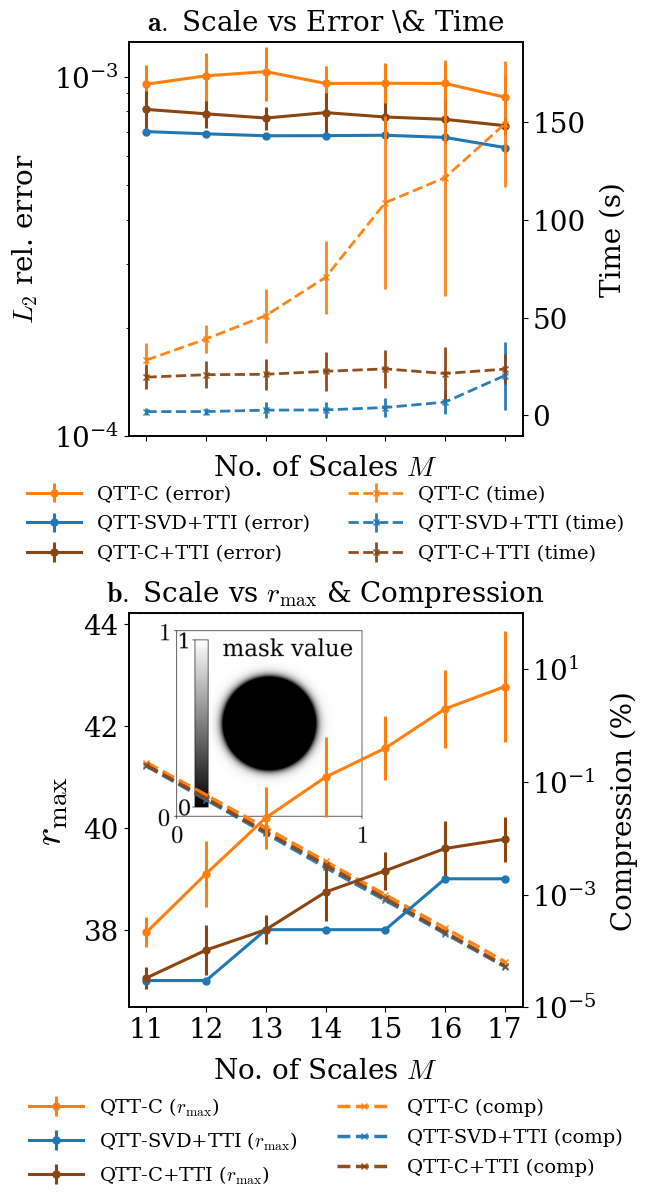

In [51]:
# circle_mask_results_formatted_like_wing.py
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.ticker import (
    MaxNLocator, LogFormatterSciNotation,
    LogLocator, LogFormatterMathtext, FuncFormatter
)
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg

# ── Style: match your reference (fonts/line widths)
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 11,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})
plt.rcParams["axes.grid"] = False

# ── Load & aggregate
CIRCLE_PATH = "./data/masks/circle_results_lr.jsonl"
records = []
with open(CIRCLE_PATH, "r") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(["method", "scale"])
      .agg(
          error_mean=("error", "mean"),
          error_std =("error", "std"),
          time_mean =("time", "mean"),
          time_std  =("time", "std"),
          rmax_mean =("rmax", "mean"),
          rmax_std  =("rmax", "std"),
          erank_mean=("erank", "mean"),
          erank_std =("erank", "std"),
      )
      .reset_index()
)

# ── Pretty names + fixed colors (as requested)
label_map = {
    "cross":     r"QTT-C",
    "cross_int": r"QTT-C+TTI",
    "svd_int":   r"QTT-SVD+TTI",
}
color_map = {
    "cross":     "tab:orange",
    "svd_int":   "tab:blue",
    "cross_int": "saddlebrown",  # brown
}

# Keep a stable method order (cross, svd_int, cross_int, then anything else)
methods_raw = list(stats["method"].unique())
preferred_order = ["cross", "svd_int", "cross_int"]
methods = [m for m in preferred_order if m in methods_raw] + [m for m in methods_raw if m not in preferred_order]

def pretty(m):  # fallback if an unexpected method appears
    return label_map.get(m, m)

def mcolor(m):
    return color_map.get(m, "tab:gray")

# ── Figure (2×1), share x — same size/layout as the wing plot
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(9.2, 14.2), sharex=True)
ax2 = ax1.twinx()   # time axis
ax4 = ax3.twinx()   # compression axis

# ── Choose dimension for compression formula:
# circle mask is 2D -> DIM=2. (Use 3 for 3D volumes.)
DIM = 2

# --- (a) Error (log) & Time ---
for method in methods:
    d = stats[stats["method"] == method].sort_values("scale")
    c = mcolor(method)
    name = pretty(method)

    # Error (solid)
    ax1.errorbar(
        d["scale"], d["error_mean"], yerr=d["error_std"],
        marker="o", linestyle="-", color=c,
        label=rf"{name} (error)", capsize=0, linewidth=2.2, markersize=5
    )
    # Time (dashed)
    ax2.errorbar(
        d["scale"], d["time_mean"], yerr=d["time_std"],
        marker="x", linestyle="--", color=c, alpha=0.95,
        label=rf"{name} (time)", capsize=0, linewidth=2.0, markersize=5
    )

ax1.set_yscale("log")
ax1.set_yticks([1e-4, 1e-3])  # keep explicit ticks like your wing version
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_xlabel(r"No. of Scales $M$", labelpad=10)

ax1.set_ylabel(r"$L_2$ rel. error", labelpad=10)
ax2.set_ylabel(r"Time (s)", labelpad=10)
ax1.set_title(r"$\mathbf{a.}$ Scale vs Error \& Time", pad=8)

# Make top panel square-ish
try:
    ax1.set_box_aspect(1.0)
except Exception:
    pass

# Legend BELOW the top plot (combined, centered)
LEG_Y  = -0.2
N_COLS = 2
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc="upper center", bbox_to_anchor=(0.5, LEG_Y),
    frameon=False, fontsize=14, handlelength=2.8,
    labelspacing=0.6, borderpad=-2, ncol=N_COLS
)

# --- (b) r_max (left) & Compression (right, log) ---

# First pass: compute global robust log-limits for compression (shared across methods)
comp_lows, comp_highs = [], []
for method in methods:
    d = stats[stats["method"] == method].sort_values("scale")
    M = d["scale"].to_numpy(dtype=float)

    r  = d["erank_mean"].to_numpy(dtype=float)
    rs = d["erank_std"].to_numpy(dtype=float)

    comp_ratio     = (DIM * M * r**2)  / (2.0 ** (DIM * M))
    comp_ratio_std = (DIM * M * rs**2) / (2.0 ** (DIM * M))

    comp_lo = np.clip((comp_ratio - comp_ratio_std) * 100.0, 1e-12, None)
    comp_hi = (comp_ratio + comp_ratio_std) * 100.0

    comp_lows.append(float(np.nanmin(comp_lo)))
    comp_highs.append(float(np.nanmax(comp_hi)))

# robust log limits (with sensible anchors)
cmin = float(min(comp_lows + [1e-4]))
cmax = float(max(comp_highs + [100.0]))
lo_dec = 10 ** np.floor(np.log10(cmin))
hi_dec = 10 ** np.ceil(np.log10(cmax))

ax4.set_yscale("log")
ax4.set_ylim(lo_dec, hi_dec)
ax4.yaxis.set_major_locator(LogLocator(base=10))
ax4.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
ax4.yaxis.set_minor_formatter(FuncFormatter(lambda *_: ""))

# 100% reference line
ax4.axhline(y=100, color="gray", linestyle="--", alpha=0.5, linewidth=1)

# Second pass: plot rmax + compression
for method in methods:
    d = stats[stats["method"] == method].sort_values("scale")
    M = d["scale"].to_numpy(dtype=float)
    c = mcolor(method)
    name = pretty(method)

    # r_max (left)
    ax3.errorbar(
        M, d["rmax_mean"], yerr=d["rmax_std"],
        marker="o", linestyle="-", color=c,
        label=rf"{name} ($r_{{\max}}$)", capsize=0, linewidth=2.2, markersize=5
    )

    # compression (right) from erank
    r  = d["erank_mean"].to_numpy(dtype=float)
    rs = d["erank_std"].to_numpy(dtype=float)

    comp_ratio     = (DIM * M * r**2)  / (2.0 ** (DIM * M))
    comp_ratio_std = (DIM * M * rs**2) / (2.0 ** (DIM * M))

    comp    = comp_ratio * 100.0
    comp_lo = np.clip((comp_ratio - comp_ratio_std) * 100.0, 1e-12, None)
    comp_hi = (comp_ratio + comp_ratio_std) * 100.0

    ax4.plot(M, comp, "--x", color=c, alpha=0.95, ms=5, label=rf"{name} (comp)")
    ax4.fill_between(M, comp_lo, comp_hi, color=c, alpha=0.12, linewidth=0)

ax3.set_xlabel(r"No. of Scales $M$", labelpad=10)
ax3.set_ylabel(r"$r_{\max}$", labelpad=10,size=28)
ax4.set_ylabel(r"Compression (%)", labelpad=10)
ax3.set_title(r"$\mathbf{b.}$ Scale vs $r_{\max}$ & Compression", pad=8)
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

# Make bottom panel square-ish
try:
    ax3.set_box_aspect(1.0)
except Exception:
    pass

# Legend BELOW the bottom plot (combine both axes)
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(
    lines3 + lines4, labels3 + labels4,
    loc="upper center", bbox_to_anchor=(0.5, LEG_Y),
    frameon=False, fontsize=14, handlelength=2.8,
    labelspacing=0.6, borderpad=0, ncol=N_COLS
)

# ── Inset image centered in the bottom panel (circle)
img_mid = mpimg.imread("./figures/circle.png")
# Put inset at (x0,y0) in ax3 axes-fraction coords, with size as a fraction too
x0, y0 = 0.04, 0.39          # <-- move these
w, h   = 0.6, 0.6          # <-- size (fraction of ax3)

axins = inset_axes(
    ax3,
    width="100%", height="100%",
    bbox_to_anchor=(x0, y0, w, h),
    bbox_transform=ax3.transAxes,
    borderpad=0
)

axins.imshow(img_mid)
axins.axis("off")
# put inset behind + make its background transparent
axins.set_zorder(-10)                 # very low zorder
axins.patch.set_alpha(0.0)            # transparent inset backg
ax3.set_zorder(1)
ax3.patch.set_visible(False)
# Thicken spines
for ax in (ax1, ax2, ax3, ax4):
    for s in ax.spines.values():
        s.set_linewidth(1.2)

# Extra bottom margin so legends have room underneath each subplot
fig.subplots_adjust(left=0.12, right=0.98, top=0.92, bottom=0.24, hspace=0.45)

# Save
out_dir = "./plots"
os.makedirs(out_dir, exist_ok=True)

# NOTE: bbox_inches='tight' can sometimes trim legends placed outside axes.
# If that happens, remove bbox_inches='tight' (or increase bottom=... above).
fig.savefig(os.path.join(out_dir, "circle_mask_results.pdf"),
            format="pdf", bbox_inches="tight", facecolor="white")
fig.savefig(os.path.join(out_dir, "circle_mask_results.png"),
            dpi=200, bbox_inches="tight", facecolor="white")

plt.show()


## Wing Mask

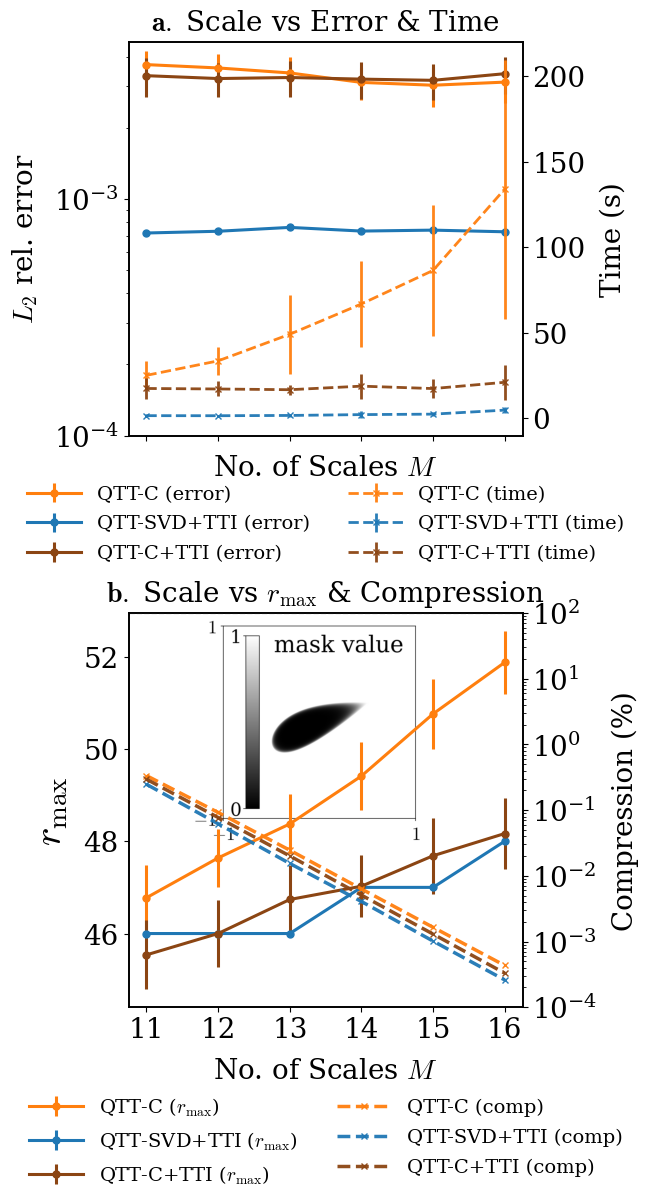

In [50]:
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.ticker import (
    MaxNLocator, LogFormatterSciNotation,
    LogLocator, LogFormatterMathtext, FuncFormatter
)
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg

# ── Style: match your reference (fonts/line widths)
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 11,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})
plt.rcParams["axes.grid"] = False

# ── Load & aggregate
records = []
with open("./data/masks/wing_results_lr.jsonl", "r") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(["method", "scale"])
      .agg(
          error_mean=("error", "mean"),
          error_std =("error", "std"),
          time_mean =("time", "mean"),
          time_std  =("time", "std"),
          rmax_mean =("rmax", "mean"),
          rmax_std  =("rmax", "std"),
          erank_mean=("erank", "mean"),
          erank_std =("erank", "std"),
      )
      .reset_index()
)

# ── Pretty names + fixed colors (as requested)
label_map = {
    "cross":     r"QTT-C",
    "cross_int": r"QTT-C+TTI",
    "svd_int":   r"QTT-SVD+TTI",
}
color_map = {
    "cross":     "tab:orange",
    "svd_int":   "tab:blue",
    "cross_int": "saddlebrown",  # brown
}

# Keep a stable method order (cross, svd_int, cross_int, then anything else)
methods_raw = list(stats["method"].unique())
preferred_order = ["cross", "svd_int", "cross_int"]
methods = [m for m in preferred_order if m in methods_raw] + [m for m in methods_raw if m not in preferred_order]

def pretty(m):
    return label_map.get(m, m)

def mcolor(m):
    return color_map.get(m, "tab:gray")

# ── Figure (2×1), share x
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(9.2, 14.2), sharex=True)
ax2 = ax1.twinx()   # time axis
ax4 = ax3.twinx()   # compression axis

# ── Choose dimension for compression formula:
# wing mask is 3D -> DIM=3
DIM = 2

# --- (a) Error (log) & Time ---
for method in methods:
    d = stats[stats["method"] == method].sort_values("scale")
    c = mcolor(method)
    name = pretty(method)

    ax1.errorbar(
        d["scale"], d["error_mean"], yerr=d["error_std"],
        marker="o", linestyle="-", color=c,
        label=rf"{name} (error)", capsize=0, linewidth=2.2, markersize=5
    )
    ax2.errorbar(
        d["scale"], d["time_mean"], yerr=d["time_std"],
        marker="x", linestyle="--", color=c, alpha=0.95,
        label=rf"{name} (time)", capsize=0, linewidth=2.0, markersize=5
    )

ax1.set_yscale("log")
ax1.set_yticks([1e-4, 1e-3])  # keep your explicit ticks
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_xlabel(r"No. of Scales $M$", labelpad=10)

ax1.set_ylabel(r"$L_2$ rel. error", labelpad=10)
ax2.set_ylabel(r"Time (s)", labelpad=10)
ax1.set_title(r"$\mathbf{a.}$ Scale vs Error & Time", pad=8)

try:
    ax1.set_box_aspect(1.0)
except Exception:
    pass

# Legend BELOW the top plot (combine lines from both axes)
LEG_Y  = -0.2
N_COLS = 2
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc="upper center", bbox_to_anchor=(0.5, LEG_Y),
    frameon=False, fontsize=14, handlelength=2.8,
    labelspacing=0.6, borderpad=-2, ncol=N_COLS
)

# --- (b) r_max (left) & Compression (right, log) ---

# First pass: compute global robust log-limits for compression (shared across methods)
comp_lows, comp_highs = [], []
for method in methods:
    d = stats[stats["method"] == method].sort_values("scale")
    M = d["scale"].to_numpy(dtype=float)

    r  = d["erank_mean"].to_numpy(dtype=float)
    rs = d["erank_std"].to_numpy(dtype=float)

    comp_ratio     = (DIM * M * r**2)  / (2.0 ** (DIM * M))
    comp_ratio_std = (DIM * M * rs**2) / (2.0 ** (DIM * M))

    comp_lo = np.clip((comp_ratio - comp_ratio_std) * 100.0, 1e-12, None)
    comp_hi = (comp_ratio + comp_ratio_std) * 100.0

    comp_lows.append(float(np.nanmin(comp_lo)))
    comp_highs.append(float(np.nanmax(comp_hi)))

# robust log limits (with sensible anchors)
cmin = float(min(comp_lows + [1e-4]))
cmax = float(max(comp_highs + [100.0]))
lo_dec = 10 ** np.floor(np.log10(cmin))
hi_dec = 10 ** np.ceil(np.log10(cmax))

ax4.set_yscale("log")
ax4.set_ylim(lo_dec, hi_dec)
ax4.yaxis.set_major_locator(LogLocator(base=10))
ax4.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
ax4.yaxis.set_minor_formatter(FuncFormatter(lambda *_: ""))

# 100% reference line
ax4.axhline(y=100, color="gray", linestyle="--", alpha=0.5, linewidth=1)

# Second pass: plot rmax + compression
for method in methods:
    d = stats[stats["method"] == method].sort_values("scale")
    M = d["scale"].to_numpy(dtype=float)
    c = mcolor(method)
    name = pretty(method)

    ax3.errorbar(
        M, d["rmax_mean"], yerr=d["rmax_std"],
        marker="o", linestyle="-", color=c,
        label=rf"{name} ($r_{{\max}}$)", capsize=0, linewidth=2.2, markersize=5
    )

    r  = d["erank_mean"].to_numpy(dtype=float)
    rs = d["erank_std"].to_numpy(dtype=float)

    comp_ratio     = (DIM * M * r**2)  / (2.0 ** (DIM * M))
    comp_ratio_std = (DIM * M * rs**2) / (2.0 ** (DIM * M))

    comp    = comp_ratio * 100.0
    comp_lo = np.clip((comp_ratio - comp_ratio_std) * 100.0, 1e-12, None)
    comp_hi = (comp_ratio + comp_ratio_std) * 100.0

    ax4.plot(M, comp, "--x", color=c, alpha=0.95, ms=5, label=rf"{name} (comp)")
    ax4.fill_between(M, comp_lo, comp_hi, color=c, alpha=0.12, linewidth=0)

ax3.set_xlabel(r"No. of Scales $M$", labelpad=10)
ax3.set_ylabel(r"$r_{\max}$", labelpad=10,size=28)
ax4.set_ylabel(r"Compression (%)", labelpad=10)
ax3.set_title(r"$\mathbf{b.}$ Scale vs $r_{\max}$ & Compression", pad=8)
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

try:
    ax3.set_box_aspect(1.0)
except Exception:
    pass

# Legend BELOW the bottom plot (combine both axes)
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax3.legend(
    lines3 + lines4, labels3 + labels4,
    loc="upper center", bbox_to_anchor=(0.5, LEG_Y),
    frameon=False, fontsize=14, handlelength=2.8,
    labelspacing=0.6, borderpad=0, ncol=N_COLS
)

# ── Inset image in the bottom panel (wing) — FORCE IT BEHIND EVERYTHING
img_mid = mpimg.imread("./plots/wing.png")

# Positioning: tweak these if you want (axes-fraction coords)
x0, y0 = 0.15, 0.4   # bottom-left of inset in ax3 (0..1)
w, h   = 0.6, 0.6   # size of inset (0..1)

axins = inset_axes(
    ax3,
    width="100%", height="100%",
    bbox_to_anchor=(x0, y0, w, h),
    bbox_transform=ax3.transAxes,
    borderpad=0
)

axins.imshow(img_mid)
axins.axis("off")

# Make sure inset is behind ALL plotted artists
axins.set_zorder(-10)
axins.patch.set_alpha(0.0)     # transparent inset background
ax3.patch.set_alpha(0.0)       # transparent main axes background so inset shows through

# (Optional) also send compression axis background transparent
ax4.patch.set_alpha(0.0)

# Thicken spines
for ax in (ax1, ax2, ax3, ax4):
    for s in ax.spines.values():
        s.set_linewidth(1.2)

# Extra bottom margin so legends have room underneath each subplot
fig.subplots_adjust(left=0.12, right=0.98, top=0.92, bottom=0.24, hspace=0.45)

# Save
out_dir = "./plots"
os.makedirs(out_dir, exist_ok=True)

# NOTE: bbox_inches='tight' can trim legends outside axes. If that happens, remove it.
fig.savefig(os.path.join(out_dir, "wing_mask_results.pdf"),
            format="pdf", bbox_inches="tight", facecolor="white")
fig.savefig(os.path.join(out_dir, "wing_mask_results.png"),
            dpi=200, bbox_inches="tight", facecolor="white")

plt.show()


## 3D mask

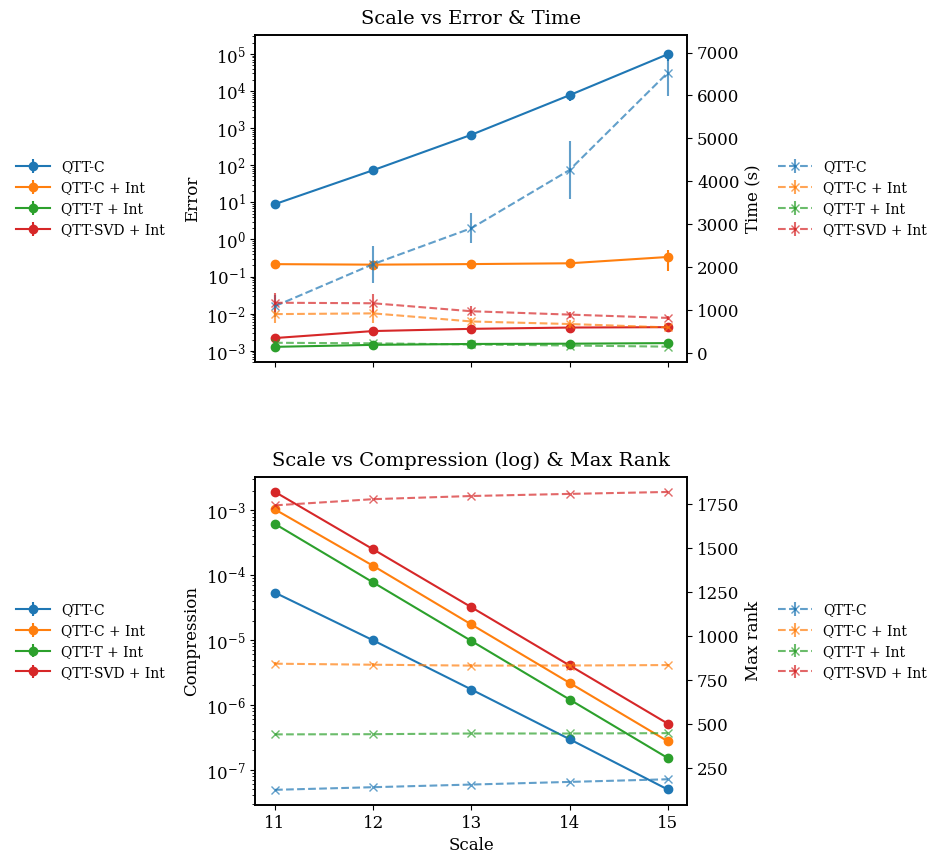

In [1]:
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation

# 1) LaTeX style: serif font + Computer Modern mathtext
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Load & aggregate
records = []
with open('./data/3d_wing_c10.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(['method', 'scale'])
      .agg({
          'error': ['mean', 'std'],
          'time':  ['mean', 'std'],
          'rmax':  ['mean', 'std'],
          'erank': ['mean', 'std']
      })
      .reset_index()
)

stats.columns = [
    'method','scale',
    'error_mean','error_std',
    'time_mean','time_std',
    'rmax_mean','rmax_std',
    'erank_mean','erank_std'
]

# Alias "erank" as "compression" for clarity in plotting
stats['compression_mean'] = stats['erank_mean']
stats['compression_std']  = stats['erank_std']

# --- New: pretty labels for methods ---
label_map = {
    'cross':        'QTT-C',
    'cross_int':    'QTT-C + Int',
    'qtt-tucker':   'QTT-T + Int',
    'qtt_tucker':   'QTT-T + Int',   # just in case
    'svd_int':      'QTT-SVD + Int',
}

methods = stats['method'].unique()
colors  = sns.color_palette('tab10', n_colors=len(methods))

# 3) Create 2×1 figure, share x-axis (white backgrounds)
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
fig.patch.set_facecolor('white')
ax1.set_facecolor('white'); ax3.set_facecolor('white')

ax2 = ax1.twinx()  # right axis for Time
ax4 = ax3.twinx()  # right axis for rmax
ax2.set_facecolor('white'); ax4.set_facecolor('white')

def nice_name(m):
    return label_map.get(m, m)

# --- Top: Error (log, left) & Time (right) ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    name = nice_name(method)

    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', label=f'{name} • error',
        color=colors[i], zorder=3
    )
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', label=f'{name} • time',
        color=colors[i], alpha=0.7, zorder=2
    )

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_ylabel('Error', fontsize=12)
ax2.set_ylabel('Time (s)', fontsize=12)
ax1.set_title('Scale vs Error & Time', pad=8, fontsize=14)

# Separate legends: left for Error, right for Time
err_lines, err_labels = ax1.get_legend_handles_labels()
time_lines, time_labels = ax2.get_legend_handles_labels()

def strip_suffix(labels):
    # turn "Method • error" -> "Method"
    return [lab.split('•')[0].strip() for lab in labels]

leg_err = ax1.legend(
    err_lines, strip_suffix(err_labels),
    loc='center right', bbox_to_anchor=(-0.18, 0.5),
    ncol=1, frameon=False, fontsize=10, handlelength=2.5
)
leg_time = ax2.legend(
    time_lines, strip_suffix(time_labels),
    loc='center left', bbox_to_anchor=(1.18, 0.5),
    ncol=1, frameon=False, fontsize=10, handlelength=2.5
)

# --- Bottom: Compression (log, left) & Max rank (right) ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    name = nice_name(method)

    ax3.errorbar(
        d['scale'], d['compression_mean'], yerr=d['compression_std'],
        marker='o', linestyle='-', label=f'{name} • compression',
        color=colors[i], zorder=3
    )
    ax4.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='x', linestyle='--', label=f'{name} • max rank',
        color=colors[i], alpha=0.7, zorder=2
    )

ax3.set_yscale('log')
ax3.yaxis.set_major_formatter(LogFormatterSciNotation())
ax3.set_xlabel('Scale', fontsize=12)
ax3.set_ylabel('Compression', fontsize=12)
ax4.set_ylabel('Max rank', fontsize=12)
ax3.set_title('Scale vs Compression (log) & Max Rank', pad=8, fontsize=14)

# force integer ticks on the shared x-axis
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

# Separate legends: left for Compression, right for Max rank
comp_lines, comp_labels = ax3.get_legend_handles_labels()
rmax_lines, rmax_labels = ax4.get_legend_handles_labels()

leg_comp = ax3.legend(
    comp_lines, strip_suffix(comp_labels),
    loc='center right', bbox_to_anchor=(-0.18, 0.5),
    ncol=1, frameon=False, fontsize=10, handlelength=2.5
)
leg_rmax = ax4.legend(
    rmax_lines, strip_suffix(rmax_labels),
    loc='center left', bbox_to_anchor=(1.18, 0.5),
    ncol=1, frameon=False, fontsize=10, handlelength=2.5
)

# 4) Thicken spines
for ax in (ax1, ax2, ax3, ax4):
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# Make room on both sides for the outside legends
fig.subplots_adjust(left=0.28, right=0.82, hspace=0.35)

# 5) Save as PDF (white background)
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(
    os.path.join(out_dir, '3d_wing_results.pdf'),
    format='pdf', bbox_inches='tight', facecolor='white'
)

plt.show()


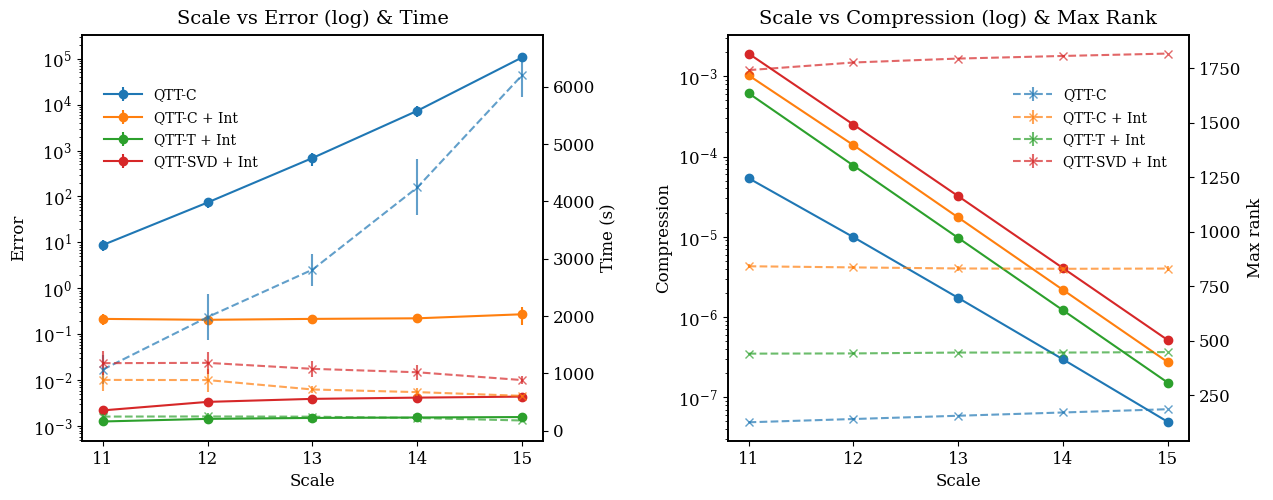

In [34]:
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation

# 1) LaTeX style: serif font + Computer Modern mathtext
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Load & aggregate
records = []
with open('./data/3d_wing_c10.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(['method', 'scale'])
      .agg({
          'error': ['mean', 'std'],
          'time':  ['mean', 'std'],
          'rmax':  ['mean', 'std'],
          'erank': ['mean', 'std']
      })
      .reset_index()
)

stats.columns = [
    'method','scale',
    'error_mean','error_std',
    'time_mean','time_std',
    'rmax_mean','rmax_std',
    'erank_mean','erank_std'
]

# Alias "erank" as "compression"
stats['compression_mean'] = stats['erank_mean']
stats['compression_std']  = stats['erank_std']

# Pretty labels for methods
label_map = {
    'cross':        'QTT-C',
    'cross_int':    'QTT-C + Int',
    'qtt-tucker':   'QTT-T + Int',
    'qtt_tucker':   'QTT-T + Int',   # just in case
    'svd_int':      'QTT-SVD + Int',
}
def nice_name(m): return label_map.get(m, m)

methods = stats['method'].unique()
colors  = sns.color_palette('tab10', n_colors=len(methods))

# 3) 1×2 figure (side-by-side)
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(13.5, 5.2), sharex=False,
                               gridspec_kw={'wspace': 0.4})
fig.subplots_adjust(left=0.10, right=0.92, top=0.92, bottom=0.14)

# Twin right axes
ax2 = ax1.twinx()  # Time
ax4 = ax3.twinx()  # Max rank

# --- Left panel: Error (log, left) & Time (right) ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    name = nice_name(method)

    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', label=f'{name} • error',
        color=colors[i], zorder=3
    )
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', label=f'{name} • time',
        color=colors[i], alpha=0.7, zorder=2
    )

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_xlabel('Scale', fontsize=12)
ax1.set_ylabel('Error', fontsize=12)
ax2.set_ylabel('Time (s)', fontsize=12)
ax1.set_title('Scale vs Error (log) & Time', pad=8, fontsize=14)

# --- Right panel: Compression (log, left) & Max rank (right) ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    name = nice_name(method)

    ax3.errorbar(
        d['scale'], d['compression_mean'], yerr=d['compression_std'],
        marker='o', linestyle='-', label=f'{name} • compression',
        color=colors[i], zorder=3
    )
    ax4.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='x', linestyle='--', label=f'{name} • max rank',
        color=colors[i], alpha=0.7, zorder=2
    )

ax3.set_yscale('log')
ax3.yaxis.set_major_formatter(LogFormatterSciNotation())
ax3.set_xlabel('Scale', fontsize=12)
ax3.set_ylabel('Compression', fontsize=12)
ax4.set_ylabel('Max rank', fontsize=12)
ax3.set_title('Scale vs Compression (log) & Max Rank', pad=8, fontsize=14)

# Integer ticks on both x-axes
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

# ================
# Legends INSIDE (split across panels)
# ================
strip_suffix = lambda labels: [lab.split('•')[0].strip() for lab in labels]

# Left-side labels (methods for Error) → first plot, top-left, slightly lower
err_lines, err_labels = ax1.get_legend_handles_labels()  # left-axis lines only
ax1.legend(
    err_lines, strip_suffix(err_labels),
    loc='upper left', bbox_to_anchor=(0.02, 0.90),  # a bit lower than the corner
    frameon=False, fontsize=10, handlelength=2.8, labelspacing=0.6
)

# Right-side labels (methods for Max rank) → second plot, top-right, slightly lower
rmax_lines, rmax_labels = ax4.get_legend_handles_labels()  # right-axis lines for panel 2
ax4.legend(
    rmax_lines, strip_suffix(rmax_labels),
    loc='upper right', bbox_to_anchor=(0.98, 0.90),
    frameon=False, fontsize=10, handlelength=2.8, labelspacing=0.6
)

# 5) Thicken spines
for ax in (ax1, ax2, ax3, ax4):
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# 6) Save
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(
    os.path.join(out_dir, '3d_wing_results.pdf'),
    format='pdf', bbox_inches='tight', facecolor='white'
)

plt.show()


In [48]:
148/5

29.6

cross QTT-C
cross QTT-C
qtt-tucker QTT-T + Int
qtt-tucker QTT-T + Int
svd_int QTT-I + Int
svd_int QTT-I + Int
cross QTT-C
cross QTT-C
qtt-tucker QTT-T + Int
qtt-tucker QTT-T + Int
svd_int QTT-I + Int
svd_int QTT-I + Int


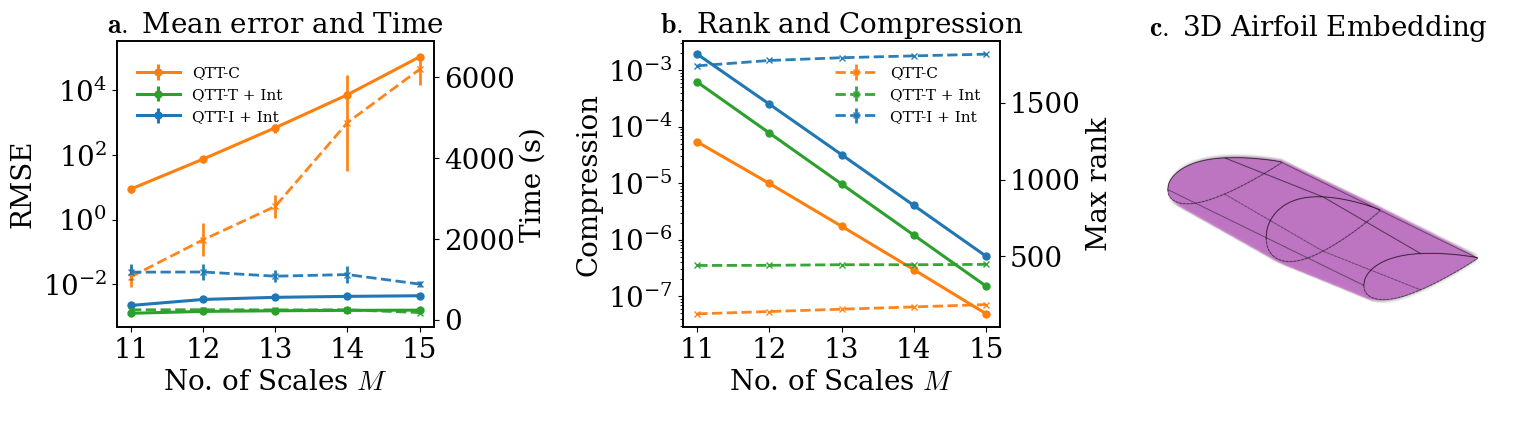

In [5]:
# three_panel_combined_formatted.py
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation

# ── Style: match your reference (fonts/line widths)
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 11,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

# ── Load data
records = []
with open('./data/3d_wing_c10.jsonl', 'r') as f:
    for ln in f:
        ln = ln.strip()
        if ln:
            records.append(json.loads(ln))
df = pd.DataFrame(records)

# ── Aggregate
stats = (
    df.groupby(['method','scale'])
      .agg(error_mean=('error','mean'),
           error_std =('error','std'),
           time_mean =('time','mean'),
           time_std  =('time','std'),
           rmax_mean =('rmax','mean'),
           rmax_std  =('rmax','std'),
           erank_mean=('erank','mean'),
           erank_std =('erank','std'))
      .reset_index()
)
stats['compression_mean'] = stats['erank_mean']
stats['compression_std']  = stats['erank_std']

# ── Pretty names
label_map = {
    'cross':        'QTT-C',
    'cross_int':    'QTT-C + Int',
    'qtt-tucker':   'QTT-T + Int',
    'qtt_tucker':   'QTT-T + Int',
    'svd_int':      'QTT-I + Int',
}
nice_name = lambda m: label_map.get(m, m)

# Keep 'cross', drop only 'cross_int'
stats = stats[stats['method'] != 'cross_int'].copy()
methods = stats['method'].unique().tolist()
# --- Fixed colors (by pretty label) ---
color_map = {
    "QTT-C": "tab:orange",
    "QTT-I + Int": "tab:blue",
    "QTT-T + Int": "tab:green",
}

def method_color(m: str) -> str:
    # fallback for any "extra" methods you might still have
    print(m,nice_name(m))
    return color_map.get(nice_name(m), "0.35")
strip_suffix = lambda labs: [s.split('•')[0].strip() for s in labs]

# ── Figure layout (GridSpec like your reference)
os.makedirs('./plots', exist_ok=True)
fig = plt.figure(figsize=(18.0, 4.2))                  # close to your 14x4, a bit wider
gs  = GridSpec(1, 3, figure=fig, width_ratios=[1.25, 1.25, 1.25])
gs.update(left=0.055, right=0.965, bottom=0.22, top=0.90, wspace=0.12)  # tighter gaps

# ── (a) Error (log) & Time (right)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = ax1.twinx()

for i, m in enumerate(methods):
    d = stats[stats['method'] == m].sort_values('scale')
    lbl = nice_name(m)
    ax1.errorbar(d['scale'], d['error_mean'], yerr=d['error_std'],
                 marker='o', linestyle='-', color=method_color(m),
                 label=f'{lbl} • error', capsize=0, linewidth=2.2, markersize=5)
    ax2.errorbar(d['scale'], d['time_mean'],  yerr=d['time_std'],
                 marker='x', linestyle='--', color=method_color(m), alpha=0.95,
                 label=f'{lbl} • time', capsize=0, linewidth=2.0, markersize=5)

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_xlabel('No. of Scales $M$')
ax1.set_ylabel('RMSE')
ax2.set_ylabel('Time (s)')
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.set_title(r"$\mathbf{a.}$ Mean error and Time", pad=6)

# Slightly wider than square
try:
    ax1.set_box_aspect(0.9)
except Exception:
    pass

# Legend: solid lines (error) only
h, l = ax1.get_legend_handles_labels()
ax1.legend(h, strip_suffix(l), frameon=False, loc="upper left",
           bbox_to_anchor=(0.02, 0.96), handlelength=2.8, labelspacing=0.5)

# ── (b) Compression (log) & Max rank (right)
ax3 = fig.add_subplot(gs[0, 1])
ax4 = ax3.twinx()

for i, m in enumerate(methods):
    d = stats[stats['method'] == m].sort_values('scale')
    lbl = nice_name(m)
    ax3.errorbar(d['scale'], d['compression_mean'], yerr=d['compression_std'],
                 marker='o', linestyle='-', color=method_color(m),
                 label=f'{lbl} • compression', capsize=0, linewidth=2.2, markersize=5)
    ax4.errorbar(d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
                 marker='x', linestyle='--', color=method_color(m), alpha=0.95,
                 label=f'{lbl} • max rank', capsize=0, linewidth=2.0, markersize=5)

ax3.set_yscale('log')
ax3.yaxis.set_major_formatter(LogFormatterSciNotation())
ax3.set_xlabel('No. of Scales $M$')
ax3.set_ylabel('Compression')
ax4.set_ylabel('Max rank')
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))
ax3.set_title(r"$\mathbf{b.}$ Rank and Compression", pad=6)

try:
    ax3.set_box_aspect(0.9)
except Exception:
    pass

# Legend: dashed lines (max rank) only
hr, lr = ax4.get_legend_handles_labels()
ax4.legend(hr, strip_suffix(lr), frameon=False, loc="upper right",
           bbox_to_anchor=(0.98, 0.96), handlelength=2.8, labelspacing=0.5)

# ── (c) 3D embedding image
ax_img = fig.add_subplot(gs[:, 2])
# --- Custom panel (c) size/position (figure fractions: [left, bottom, width, height]) ---
box = ax_img.get_position()  # current [x0, y0, w, h]
# Example: make it wider and taller while nudging left a bit so it stays inside the figure
new_box = [box.x0 - .12, box.y0 - 0.21, box.width * 1.5, box.height*1.3 ]
ax_img.set_position(new_box)

img = plt.imread('./plots/3d_embedding.png')  # ensure this path/file exists
ax_img.imshow(img)
ax_img.set_axis_off()
ax_img.set_title(r"$\mathbf{c.}$ 3D Airfoil Embedding", pad=4)



# Thicken spines for plots
for ax in (ax1, ax2, ax3, ax4):
    for s in ax.spines.values(): 
        s.set_linewidth(1.2)

# ── Save
fig.savefig('./plots/3d_wing_three_panel.pdf', bbox_inches='tight', facecolor='white')
fig.savefig('./plots/3d_wing_three_panel.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


In [29]:
import math
math.pow(2,-18*3)

5.551115123125783e-17

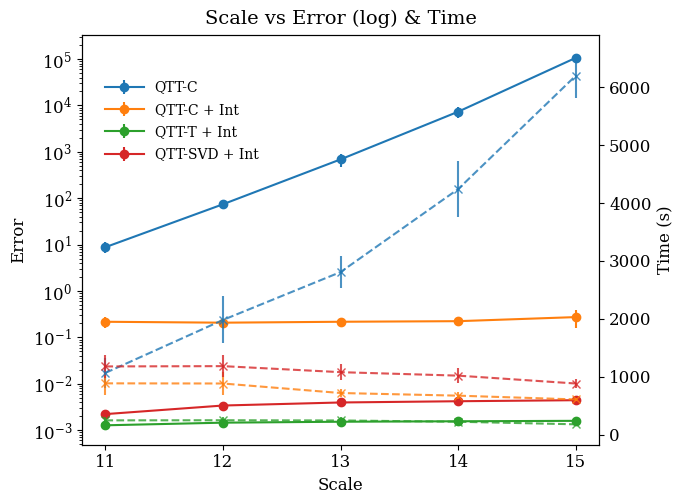

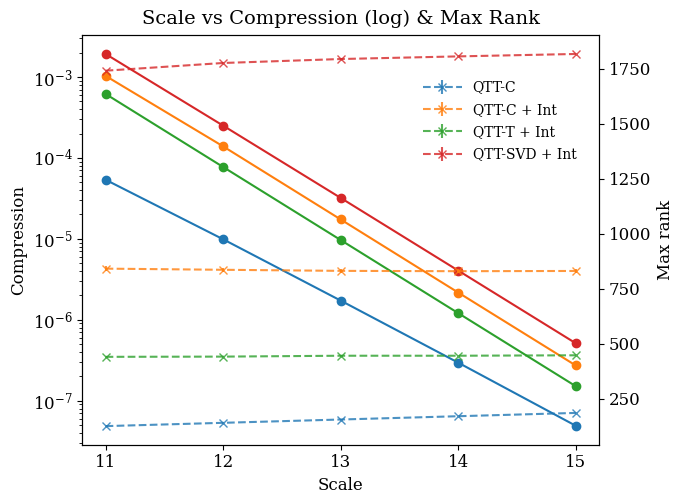

In [36]:
# save_two_panels_separately_labels_like_original.py
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation

# LaTeX-ish font
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# --- Load ---
records = []
with open('./data/3d_wing_c10.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))
df = pd.DataFrame(records)

# --- Aggregate (mean ± std) ---
stats = (
    df.groupby(['method', 'scale'])
      .agg(error_mean=('error','mean'),
           error_std =('error','std'),
           time_mean =('time','mean'),
           time_std  =('time','std'),
           rmax_mean =('rmax','mean'),
           rmax_std  =('rmax','std'),
           erank_mean=('erank','mean'),
           erank_std =('erank','std'))
      .reset_index()
)

# Alias "erank" as "compression"
stats['compression_mean'] = stats['erank_mean']
stats['compression_std']  = stats['erank_std']

# Pretty labels for methods
label_map = {
    'cross':        'QTT-C',
    'cross_int':    'QTT-C + Int',
    'qtt-tucker':   'QTT-T + Int',
    'qtt_tucker':   'QTT-T + Int',   # just in case
    'svd_int':      'QTT-SVD + Int',
}
def nice_name(m): return label_map.get(m, m)

methods = stats['method'].unique()
colors  = sns.color_palette('tab10', n_colors=len(methods))

def strip_suffix(labels):
    # "Name • error/time/..." -> "Name"
    return [lab.split('•')[0].strip() for lab in labels]

os.makedirs('./plots', exist_ok=True)

# =========================
# (a) Error (log) & Time
# =========================
fig_a, ax1 = plt.subplots(figsize=(7.0, 5.2))
ax2 = ax1.twinx()

for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    name = nice_name(method)

    # Left axis: Error (solid)
    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', label=f'{name} • error',
        color=colors[i], zorder=3
    )
    # Right axis: Time (dashed)
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', label=f'{name} • time',
        color=colors[i], alpha=0.8, zorder=2
    )

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_xlabel('Scale', fontsize=12)
ax1.set_ylabel('Error', fontsize=12)
ax2.set_ylabel('Time (s)', fontsize=12)
ax1.set_title('Scale vs Error (log) & Time', pad=8, fontsize=14)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

# ONE legend on the left figure, from SOLID (error) lines only
err_lines, err_labels = ax1.get_legend_handles_labels()
ax1.legend(
    err_lines, strip_suffix(err_labels),
    loc='upper left', bbox_to_anchor=(0.02, 0.92),
    frameon=False, fontsize=10, handlelength=2.8, labelspacing=0.6
)

fig_a.tight_layout()
fig_a.savefig('./plots/3d_wing_results_a.pdf', bbox_inches='tight', facecolor='white')
# fig_a.savefig('./plots/3d_wing_results_a.png', dpi=200, bbox_inches='tight', facecolor='white')

# =========================
# (b) Compression (log) & Max rank
# =========================
fig_b, ax3 = plt.subplots(figsize=(7.0, 5.2))
ax4 = ax3.twinx()

for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    name = nice_name(method)

    # Left axis: Compression (solid)
    ax3.errorbar(
        d['scale'], d['compression_mean'], yerr=d['compression_std'],
        marker='o', linestyle='-', label=f'{name} • compression',
        color=colors[i], zorder=3
    )
    # Right axis: Max rank (dashed)
    ax4.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='x', linestyle='--', label=f'{name} • max rank',
        color=colors[i], alpha=0.8, zorder=2
    )

ax3.set_yscale('log')
ax3.yaxis.set_major_formatter(LogFormatterSciNotation())
ax3.set_xlabel('Scale', fontsize=12)
ax3.set_ylabel('Compression', fontsize=12)
ax4.set_ylabel('Max rank', fontsize=12)
ax3.set_title('Scale vs Compression (log) & Max Rank', pad=8, fontsize=14)
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

# ONE legend on the right figure, from DASHED (max-rank) lines only
rmax_lines, rmax_labels = ax4.get_legend_handles_labels()
ax4.legend(
    rmax_lines, strip_suffix(rmax_labels),
    loc='upper right', bbox_to_anchor=(0.98, 0.92),
    frameon=False, fontsize=10, handlelength=2.8, labelspacing=0.6
)

fig_b.tight_layout()
fig_b.savefig('./plots/3d_wing_results_b.pdf', bbox_inches='tight', facecolor='white')
# fig_b.savefig('./plots/3d_wing_results_b.png', dpi=200, bbox_inches='tight', facecolor='white')

plt.show()


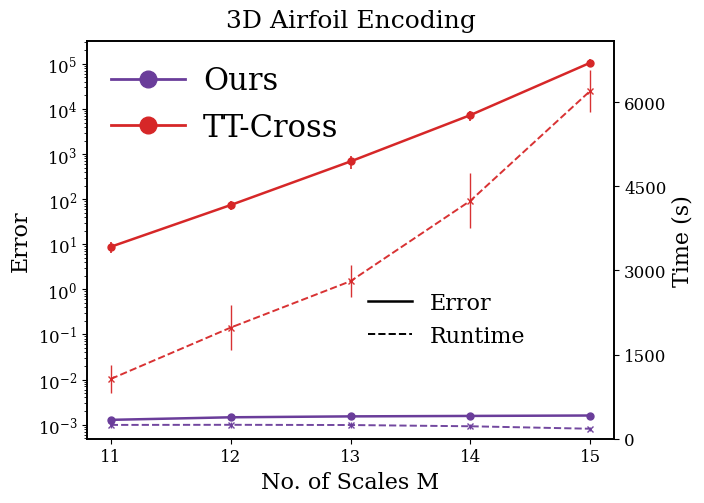

In [32]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation
from matplotlib.lines import Line2D

# LaTeX-ish font
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# --- Load ---
records = []
with open('./data/3d_wing_c10.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records.append(json.loads(line))
df = pd.DataFrame(records)

# --- Aggregate (mean ± std) ---
agg = (
    df.groupby(['method', 'scale'])
      .agg(error_mean=('error','mean'),
           error_std =('error','std'),
           time_mean =('time','mean'),
           time_std  =('time','std'))
      .reset_index()
)

# --- Pick only the two methods of interest ---
# Ours = qtt-tucker/qtt_tucker (purple), QTT-Cross = cross (red)
method_specs = [
    (['qtt-tucker', 'qtt_tucker'], 'Ours',       '#6a3d9a'),  # purple
    (['cross'],                    'QTT-Cross',  '#d62728'),  # red
]

plot_rows = []
for keys, label, color in method_specs:
    d = agg[agg['method'].isin(keys)].copy()
    if not d.empty:
        d['label'] = label
        d['color'] = color
        plot_rows.append(d)

if not plot_rows:
    raise RuntimeError("Neither 'qtt-tucker/qtt_tucker' nor 'cross' found in the data.")

plot_df = pd.concat(plot_rows, ignore_index=True)

# --- Figure: Error (left, log) & Time (right, LINEAR) ---
fig, ax_err = plt.subplots(figsize=(7.2, 5.2))
ax_time = ax_err.twinx()

for (label, color), g in plot_df.groupby(['label', 'color']):
    g = g.sort_values('scale')

    # Left axis: Error (solid)
    ax_err.errorbar(
        g['scale'], g['error_mean'], yerr=g['error_std'],
        marker='o', linestyle='-', color=color,
        capsize=0, elinewidth=1.2, linewidth=1.8, markersize=5
    )

    # Right axis: Time (dashed) — LINEAR
    ax_time.errorbar(
        g['scale'], g['time_mean'], yerr=g['time_std'],
        marker='x', linestyle='--', color=color, alpha=0.95,
        capsize=0, elinewidth=1.0, linewidth=1.4, markersize=5
    )

# Axes formatting
ax_err.set_yscale('log')
ax_err.yaxis.set_major_formatter(LogFormatterSciNotation())
ax_err.xaxis.set_major_locator(MaxNLocator(integer=True))

# --- Time axis: LINEAR + more ticks ---
# Compute padded limits from data (including error bars)
t_mean = plot_df['time_mean'].to_numpy()
t_std  = np.nan_to_num(plot_df['time_std'].to_numpy(), nan=0.0)

t_lo = float(np.nanmin(t_mean - t_std))
t_hi = float(np.nanmax(t_mean + t_std))
if not np.isfinite(t_lo) or not np.isfinite(t_hi):
    t_lo, t_hi = 0.0, 1.0
if t_lo == t_hi:
    t_hi = t_lo + 1.0

pad = 0.08 * (t_hi - t_lo)
ax_time.set_ylim(max(0.0, t_lo - pad), t_hi + pad)
ax_time.yaxis.set_major_locator(MaxNLocator(nbins=6))  # more nicely spaced ticks

# Labels & title
ax_err.set_xlabel('No. of Scales M', fontsize=16)
ax_err.set_ylabel('Error', fontsize=16)
ax_time.set_ylabel('Time (s)', fontsize=16)
ax_err.set_title('3D Airfoil Encoding', fontsize=18, pad=10)

# --- Legend 1: methods (colored line + dot) ---
COLOR_OURS  = '#6a3d9a'
COLOR_CROSS = '#d62728'
legend_handles = [
    Line2D([0], [0], linestyle='-', color=COLOR_OURS,
           marker='o', markerfacecolor=COLOR_OURS, markeredgecolor=COLOR_OURS,
           linewidth=2.0, markersize=12, label='Ours'),
    Line2D([0], [0], linestyle='-', color=COLOR_CROSS,
           marker='o', markerfacecolor=COLOR_CROSS, markeredgecolor=COLOR_CROSS,
           linewidth=2.0, markersize=12, label='TT-Cross'),
]
leg_methods = ax_err.legend(
    handles=legend_handles,
    frameon=False, fontsize=22, handlelength=2.4, handletextpad=0.6,
    borderpad=0.3, loc='best'
)

# --- Legend 2: line-style key (mid-right) ---
style_handles = [
    Line2D([0], [0], color='k', linestyle='-',  linewidth=1.8, label='Error'),
    Line2D([0], [0], color='k', linestyle='--', linewidth=1.4, label='Runtime'),
]
leg_styles = ax_err.legend(
    handles=style_handles, frameon=False, fontsize=16,
    loc='center right', bbox_to_anchor=(0.87, 0.3), title_fontsize=11
)
ax_err.add_artist(leg_methods)

# Spines
for ax in (ax_err, ax_time):
    for s in ax.spines.values():
        s.set_linewidth(1.2)

fig.tight_layout()

# Save (optional)
os.makedirs('./plots', exist_ok=True)
fig.savefig('./plots/error_time_Ours_vs_QTT-Cross_linearTime.pdf',
            bbox_inches='tight', facecolor='white')
fig.savefig('./plots/error_time_Ours_vs_QTT-Cross_linearTime.png',
            dpi=200, bbox_inches='tight', facecolor='white')

plt.show()


# Turbulence

## individual metrics

-0.4221034917164266


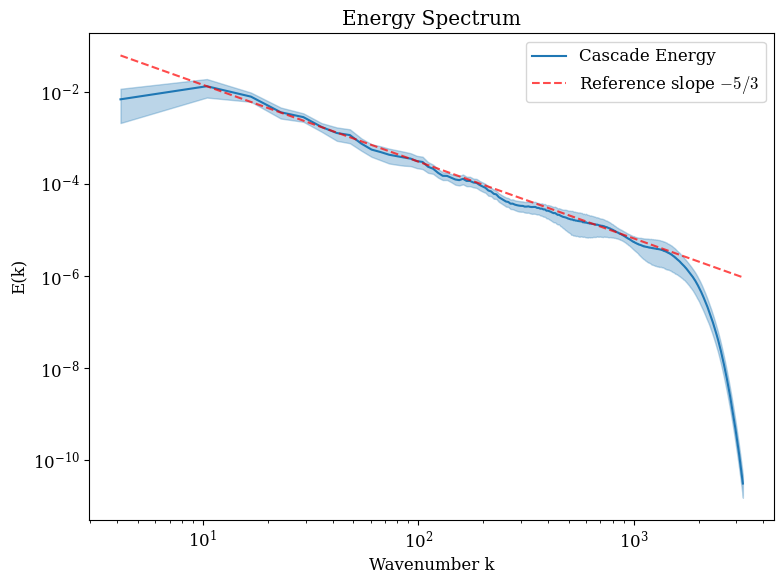

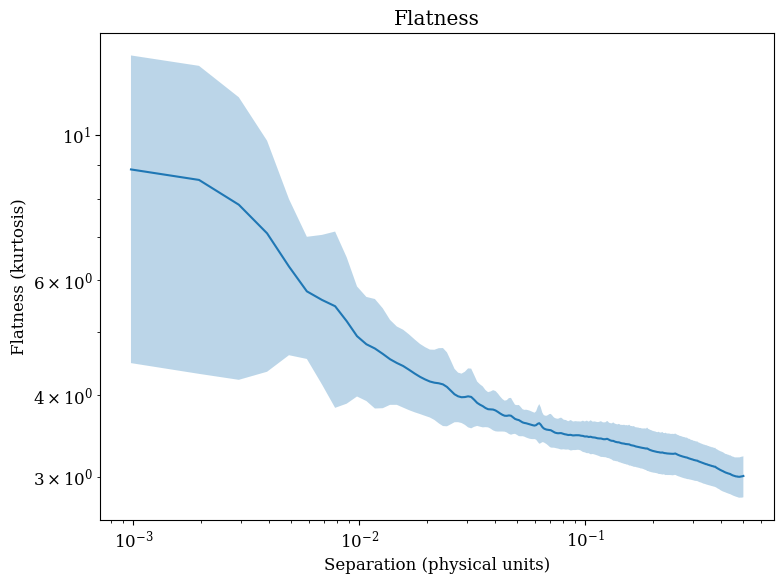

'\n# 2) Scaling exponent of the energy spectrum\nscaling = np.log(E_mean) / np.log(k)\n# Error propagation: σ_S = σ_E / (E_mean * |ln(k)|)\nsigma_scaling = E_std / (E_mean * np.abs(np.log(k)))\n# Plot scaling exponent with error shading\nplt.figure(figsize=(8, 6))\nplt.plot(k, scaling, label=\'Scaling exponent\')\nplt.fill_between(k, scaling - sigma_scaling, scaling + sigma_scaling, alpha=0.3, label=\'±1σ error\')\nplt.title("Scaling Exponent of Energy Spectrum")\nplt.show()\n'

In [9]:
# Load previously saved data
df_energy    = pd.read_csv('./data/turbulence/energy_comb10_e12.csv')
df_flatness  = pd.read_csv('./data/turbulence/flatness_comb10_e12.csv')

# Drop rows where separation is NaN
# df_flatness = df_flatness.dropna(subset=['separation'])

# 1) Energy statistics: mean and std over runs at each k_center
energy_stats = df_energy.groupby('k_center')['E_k'].agg(['mean', 'std']).reset_index()
k      = energy_stats['k_center'].values
E_mean = energy_stats['mean'].values
E_std  = energy_stats['std'].values

# --- Linear fit on the window where 2 <= k <= 300 ---
# mask = (k >= 2) & (k <= 300)
# log_k_fit = np.log(k[mask])
# log_E_fit = np.log(E_mean[mask])
# slope, intercept, *_ = linregress(log_k_fit, log_E_fit)
# fit_line = np.exp(intercept + slope * np.log(k))  # for full overlay

# --- Reference line with slope -5/3 ---
k_ref = np.linspace(k.min(), k.max(), 200)
ref_slope = -5/3
# Choose reference level so that it matches roughly the curve height
ref_intercept = np.log(E_mean[ (k > 10) & (k < 400) ][0]) - ref_slope * np.log(k[(k > 10) & (k < 400)][0])
print(ref_intercept)
ref_line = np.exp(ref_intercept) * k_ref**(ref_slope)

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.loglog(k, E_mean, label='Cascade Energy', color='tab:blue')
plt.fill_between(k, E_mean - E_std, E_mean + E_std, alpha=0.3, color='tab:blue')
# plt.loglog(k, fit_line, '--', color='red', alpha=0.5, label=f"Fit: slope = {slope:.2f}")
plt.loglog(k_ref, ref_line, '--', color='red', alpha=0.7, label=r"Reference slope $-5/3$")

plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.title("Energy Spectrum")
plt.legend()
plt.tight_layout()
plt.savefig("./plots/energy.pdf", format='pdf')
plt.show()

# 3) Flatness statistics: mean and std over runs at each separation
flat_stats = df_flatness.groupby('separation')['flatness'].agg(['mean', 'std']).reset_index()
s       = flat_stats['separation'].values
F_mean  = flat_stats['mean'].values
F_std   = flat_stats['std'].values

# Plot flatness vs separation in log-log space
plt.figure(figsize=(8, 6))
plt.loglog(s, F_mean, label='Cascade Flatness')
plt.fill_between(s, F_mean - F_std, F_mean + F_std, alpha=0.3)
plt.xlabel("Separation (physical units)")
plt.ylabel("Flatness (kurtosis)")
plt.title("Flatness")
#plt.legend()
plt.tight_layout()
plt.savefig("./plots/flatness.pdf", format='pdf')
plt.show()

"""
# 2) Scaling exponent of the energy spectrum
scaling = np.log(E_mean) / np.log(k)
# Error propagation: σ_S = σ_E / (E_mean * |ln(k)|)
sigma_scaling = E_std / (E_mean * np.abs(np.log(k)))
# Plot scaling exponent with error shading
plt.figure(figsize=(8, 6))
plt.plot(k, scaling, label='Scaling exponent')
plt.fill_between(k, scaling - sigma_scaling, scaling + sigma_scaling, alpha=0.3, label='±1σ error')
plt.title("Scaling Exponent of Energy Spectrum")
plt.show()
"""


## all plots


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter, LogLocator, LogFormatterMathtext
from scipy.stats import linregress
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg

from pysciplottk import EasyPlotter

# ── Snapshot for panel (a)
image = mpimg.imread("snapshot_cube.png")

# ====== Original (QTT-I) ======
df = pd.read_csv("./data/turbulence/rqttV5c2_1em8_p.csv")
stats  = df.groupby("Dimension")["MaxRank"].agg(["mean", "std"]).reset_index()
stats2 = df.groupby("Dimension")["ERank"].agg(["mean", "std"]).reset_index()
M         = stats["Dimension"].values
chi_mean  = stats["mean"].values
chi_std   = stats["std"].values
erank_mean = stats2["mean"].values
erank_std  = stats2["std"].values

# χ fit (QTT-I)
slope, intercept, *_ = linregress(df["Dimension"], df["MaxRank"])

# Flatness (QTT-I)
df_flatness = pd.read_csv("./data/turbulence/qttflatness10_8.csv")
flat_stats = df_flatness.groupby("separation")["flatness"].agg(["mean", "std"]).reset_index()
s      = flat_stats["separation"].values
F_mean = flat_stats["mean"].values
F_std  = flat_stats["std"].values

# Energy (QTT-I)
df_energy = pd.read_csv("./data/turbulence/qttenergy10_c.csv")
energy_stats = df_energy.groupby("k_center")["E_k"].agg(["mean", "std"]).reset_index()
k     = energy_stats["k_center"].values
E_mea = energy_stats["mean"].values
E_std = energy_stats["std"].values

# ====== Combined (QTT-T) ======
df_c = pd.read_csv("./data/turbulence/rcg_200_10_e8_o2.csv")  # updated file
df_c = df_c[df_c["Dimension"] <= 12]

# χ stats + fit (QTT-T)
stats_c   = df_c.groupby("Dimension")["MaxRank"].agg(["mean","std"]).reset_index()
M_c        = stats_c["Dimension"].values
chi_mean_c = stats_c["mean"].values
chi_std_c  = stats_c["std"].values
slope_c, intercept_c, *_ = linregress(df_c["Dimension"], df_c["MaxRank"])

# Energy (QTT-T)
df_energy_c    = pd.read_csv("./data/turbulence/energy_comb10_e12.csv")
energy_stats_c = df_energy_c.groupby("k_center")["E_k"].agg(["mean","std"]).reset_index()
k_c     = energy_stats_c["k_center"].values
E_mea_c = energy_stats_c["mean"].values
E_std_c = energy_stats_c["std"].values

# Flatness (QTT-T)
df_flatness_c = pd.read_csv("./data/turbulence/flatness_comb10_e12.csv")
flat_stats_c = df_flatness_c.groupby("separation")["flatness"].agg(["mean","std"]).reset_index()
s_c      = flat_stats_c["separation"].values
F_mean_c = flat_stats_c["mean"].values
F_std_c  = flat_stats_c["std"].values

# ====== Power-law guides k^{-5/3} ======
ref_slope = -5/3
def power_guide(x, y, slope, lo=10, hi=400):
    x = np.asarray(x); y = np.asarray(y)
    mask = (x > max(lo, x.min()*1.5)) & (x < min(hi, x.max()/1.5))
    idx = np.where(mask)[0][0] if np.any(mask) else len(x)//2
    b = np.log(y[idx]) - slope*np.log(x[idx])
    xr = np.linspace(x.min(), x.max(), 200)
    yr = np.exp(b) * xr**slope
    return xr, yr

k_ref,   ref_line   = power_guide(k,   E_mea,   ref_slope)
k_ref_c, ref_line_c = power_guide(k_c, E_mea_c, ref_slope)

# ──────────────────────────────────────────────────────────────────────
# SIZE CONFIG (exactly as requested)
plotter = EasyPlotter("synthetic_results.pdf", "latex,revtex")
fig = plotter.wide_figure()
fig.set_size_inches(w=14.0, h=4)
gs = GridSpec(1, 3, figure=fig, width_ratios=[1.0, 1.0, 1.0])
gs.update(left=0.043, right=0.90, bottom=0.23, top=0.92, wspace=.25)

plt.rcParams.update({
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 16,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

axs = [fig.add_subplot(gs[0, i]) for i in range(3)]

# ── (a) Energy spectrum ──────────────────────────────────────────────
# Curves
line_I,  = axs[0].loglog(k,   E_mea,   color="tab:blue",  label="QTT-I")
axs[0].fill_between(k, E_mea - E_std, E_mea + E_std, alpha=0.30, color="tab:blue")
line_T,  = axs[0].loglog(k_c, E_mea_c, color="tab:green", label="QTT-T")
axs[0].fill_between(k_c, E_mea_c - E_std_c, E_mea_c + E_std_c, alpha=0.22, color="tab:green")

# Two k^{-5/3} guides (no legend labels)
axs[0].loglog(k_ref,   ref_line,   "--", color="tab:red")
axs[0].loglog(k_ref_c, ref_line_c, "--", color="tab:purple")

# Keep legend for the two data curves only
axs[0].legend(handles=[line_I, line_T], frameon=False, loc="upper right")

# Lower-right in-axes label for the guides (two colored swatches + one text)
x0, x1 = 0.78, 0.84         # swatch start/end (axes coords)
yR, yP = 0.09, 0.04         # stacked rows near lower-right
axs[0].plot([x0, x1], [yR, yR], transform=axs[0].transAxes, color="tab:red", linestyle="--",   lw=2, clip_on=False)
axs[0].plot([x0, x1], [yP, yP], transform=axs[0].transAxes, color="tab:purple", lw=2, linestyle="--",clip_on=False)
axs[0].text(0.85, 0.057, r"$k^{-5/3}$", transform=axs[0].transAxes,
            ha="left", va="center", fontsize=12, color="0.15")

axs[0].set_xlabel(r"$k = \sqrt{k_x^2 + k_y^2 + k_z^2}$")
axs[0].set_title(r"\textbf{a.} Energy Spectrum $E(k)$")


# Insert the snapshot image EXACTLY like your working example (after plotting)
inset_ax = inset_axes(
    axs[0],
    width="55%",
    height="55%",
    loc="lower left",
    bbox_to_anchor=(-0.05, -0.02, 1.1, 1.1),
    bbox_transform=axs[0].transAxes,
)
inset_ax.imshow(image)
inset_ax.axis("off")

# ── (b) Flatness ─────────────────────────────────────────────────────
axs[1].loglog(s,   F_mean,   color="tab:blue",  label="QTT-I")
axs[1].fill_between(s, F_mean - F_std, F_mean + F_std, alpha=0.30, color="tab:blue")
axs[1].loglog(s_c, F_mean_c, color="tab:green", label="QTT-T")
axs[1].fill_between(s_c, F_mean_c - F_std_c, F_mean_c + F_std_c, alpha=0.22, color="tab:green")

axs[1].set_xlabel(r"Separation $r$")
axs[1].axhline(y=min(F_mean.min(), F_mean_c.min()), color="black", linestyle="--",
               alpha=0.7, label=r"zero-intermittency")
axs[1].set_title(r"\textbf{b.} Flatness (kurtosis)")
axs[1].legend(frameon=False, loc="upper right")
for axis in [axs[1].yaxis]:
    axis.set_major_formatter(FuncFormatter(lambda y, _: "{:g}".format(y)))
    axis.set_minor_formatter(FuncFormatter(lambda y, _: "{:g}".format(y)))

# ── (c) χ vs M with BOTH compressions ───────────────────────────────
# χ points (no labels)
axs[2].errorbar(M,  chi_mean,  yerr=chi_std,  fmt="o", color="tab:blue")
axs[2].errorbar(M_c, chi_mean_c, yerr=chi_std_c, fmt="o", color="tab:green")

# χ slope lines + CENTER-TOP text labels (no bullets/lines)
axs[2].plot(M,  intercept + slope*M,   "--", color="tab:blue", linewidth=2)
axs[2].plot(M_c, intercept_c + slope_c*M_c, "--", color="tab:green",linewidth=2)
#axs[2].text(0.50, 0.96, rf"$\chi \propto {slope:.1f}M$ (QTT\!-\!I)",
#            transform=axs[2].transAxes, ha="center", va="top",
#            color="crimson", fontsize=13)
#axs[2].text(0.50, 0.88, rf"$\chi \propto {slope_c:.1f}M$ (QTT\!-\!T)",
#            transform=axs[2].transAxes, ha="center", va="top",
#            color="tab:olive", fontsize=13)

# Compression (right axis)
comp_ratio     = (3 * M  * erank_mean**2) / (2 ** (3 * M))
comp_ratio_std = (3 * M  * erank_std**2)  / (2 ** (3 * M))
comp_I    = comp_ratio * 100.0
comp_I_lo = np.clip((comp_ratio - comp_ratio_std) * 100.0, 1e-12, None)
comp_I_hi = (comp_ratio + comp_ratio_std) * 100.0

comp_stats = df_c.groupby("Dimension")["compression"].agg(["mean","std"]).reset_index()
Mc        = comp_stats["Dimension"].values
comp_T    = comp_stats["mean"].values
comp_Tstd = comp_stats["std"].values
if comp_T.max() <= 1.5:
    comp_T    = comp_T * 100.0
    comp_Tstd = comp_Tstd * 100.0
comp_T_lo = np.clip(comp_T - comp_Tstd, 1e-12, None)
comp_T_hi = comp_T + comp_Tstd

ax_r = axs[2].twinx()
ax_r.plot(M,  comp_I, "-s",  ms=5, color="tab:blue")
ax_r.fill_between(M,  comp_I_lo, comp_I_hi, color="tab:blue", alpha=0.12, linewidth=0)
ax_r.plot(Mc, comp_T, "-s",  ms=5, color="tab:green")
ax_r.fill_between(Mc, comp_T_lo, comp_T_hi, color="tab:green", alpha=0.10, linewidth=0)
ax_r.axhline(y=100, color="gray", linestyle="--", alpha=0.5, linewidth=1)

# Robust log limits; clamp to 1e-4 min (no 1e-10 ticks)
all_low  = np.array([comp_I_lo.min(), comp_T_lo.min(), 1e-4])
all_high = np.array([comp_I_hi.max(), comp_T_hi.max(), 100.0])
cmin = float(all_low.min())
cmax = float(all_high.max())
lo_dec = 10 ** np.floor(np.log10(cmin))
hi_dec = 10 ** np.ceil(np.log10(cmax))
ax_r.set_yscale("log")
ax_r.set_ylim(lo_dec, hi_dec)
ax_r.yaxis.set_major_locator(LogLocator(base=10))
ax_r.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
ax_r.yaxis.set_minor_formatter(FuncFormatter(lambda *_: ""))

# Compression labels (CENTER-LEFT on right axis) using short colored line swatches
def label_with_line(ax, y_ax, color, text):
    origin = 0.33
    x0, x1 = origin+0.05, origin+0.15
    ax.plot([x0, x1], [y_ax, y_ax], transform=ax.transAxes, color=color, lw=2, clip_on=False)
    ax.text(x1 + 0.02, y_ax, text, transform=ax.transAxes,
            ha="left", va="center", color="black", fontsize=11)

label_with_line(ax_r, 0.95, "tab:blue", "QTT-I")
label_with_line(ax_r, 0.89, "tab:green",     "QTT-T")

# Titles/labels (no χ label on y-axis)
axs[2].set_title(r"\textbf{c.} Max. TT-rank and Compression")
axs[2].set_xlabel("No. of scales $M$")
axs[2].set_ylabel(r"$\chi$",labelpad=0)  # intentionally omitted
ax_r.set_ylabel("Compression $(\%)$")
axs[2].xaxis.set_major_locator(plt.MaxNLocator(6, integer=True))
axs[2].yaxis.set_major_locator(plt.MaxNLocator(4))
plt.show()
# Final layout
gs.tight_layout(fig, pad=0.0)
plotter.save()


/tmp/ipykernel_3459240/3521326357.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  gs.tight_layout(fig, pad=0.0)


### first metircs

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter, LogLocator, LogFormatterMathtext
from scipy.stats import linregress
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg

from pysciplottk import EasyPlotter

# ── Snapshot for panel (a)
image = mpimg.imread("snapshot_cube.png")

# ====== QTT-I ONLY ======
df = pd.read_csv("./data/turbulence/rqttV5c2_1em8_p.csv")
stats  = df.groupby("Dimension")["MaxRank"].agg(["mean", "std"]).reset_index()
stats2 = df.groupby("Dimension")["ERank"].agg(["mean", "std"]).reset_index()

M          = stats["Dimension"].values
chi_mean   = stats["mean"].values
chi_std    = stats["std"].values
erank_mean = stats2["mean"].values
erank_std  = stats2["std"].values

# χ fit (QTT-I)
slope, intercept, *_ = linregress(df["Dimension"], df["MaxRank"])

# Flatness (QTT-I)
df_flatness = pd.read_csv("./data/turbulence/qttflatness10_8.csv")
flat_stats  = df_flatness.groupby("separation")["flatness"].agg(["mean", "std"]).reset_index()
s      = flat_stats["separation"].values
F_mean = flat_stats["mean"].values
F_std  = flat_stats["std"].values

# Energy (QTT-I)
df_energy = pd.read_csv("./data/turbulence/qttenergy10_c.csv")
energy_stats = df_energy.groupby("k_center")["E_k"].agg(["mean", "std"]).reset_index()
k     = energy_stats["k_center"].values
E_mea = energy_stats["mean"].values
E_std = energy_stats["std"].values

# ====== Power-law guide k^{-5/3} (single guide) ======
ref_slope = -5/3
def power_guide(x, y, slope, lo=10, hi=400):
    x = np.asarray(x); y = np.asarray(y)
    mask = (x > max(lo, x.min()*1.5)) & (x < min(hi, x.max()/1.5))
    idx = np.where(mask)[0][0] if np.any(mask) else len(x)//2
    b = np.log(y[idx]) - slope*np.log(x[idx])
    xr = np.linspace(x.min(), x.max(), 200)
    yr = np.exp(b) * xr**slope
    return xr, yr

k_ref, ref_line = power_guide(k, E_mea, ref_slope)

# ──────────────────────────────────────────────────────────────────────
# SIZE CONFIG
plotter = EasyPlotter("synthetic_results_qtti.pdf", "latex,revtex")
fig = plotter.wide_figure()
fig.set_size_inches(w=14.0, h=4)
gs = GridSpec(1, 3, figure=fig, width_ratios=[1.0, 1.0, 1.0])
gs.update(left=0.043, right=0.94, bottom=0.23, top=0.92, wspace=0.56)

plt.rcParams.update({
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 16,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

axs = [fig.add_subplot(gs[0, i]) for i in range(3)]

# ── (a) Energy spectrum (QTT-I only) ───────────────────────────────────
line_I, = axs[0].loglog(k, E_mea, color="tab:blue", label="QTT-I")
axs[0].fill_between(k, E_mea - E_std, E_mea + E_std, alpha=0.30, color="tab:blue")

# single k^{-5/3} guide
axs[0].loglog(k_ref, ref_line, "--", color="tab:red")

axs[0].legend(handles=[line_I], frameon=False, loc="upper right")

# small in-axes label for guide
axs[0].plot([0.78, 0.84], [0.06, 0.06], transform=axs[0].transAxes,
            color="tab:red", linestyle="--", lw=2, clip_on=False)
axs[0].text(0.85, 0.06, r"$k^{-5/3}$", transform=axs[0].transAxes,
            ha="left", va="center", fontsize=12, color="0.15")

axs[0].set_xlabel(r"$k = \sqrt{k_x^2 + k_y^2 + k_z^2}$")
axs[0].set_title(r"\textbf{a.} Energy Spectrum $E(k)$")

# snapshot inset
inset_ax = inset_axes(
    axs[0],
    width="55%", height="55%",
    loc="lower left",
    bbox_to_anchor=(-0.1, -0.02, 1.1, 1.1),
    bbox_transform=axs[0].transAxes,
)
inset_ax.imshow(image)
inset_ax.axis("off")

# ── (b) Flatness (QTT-I only) with x scaled by pi ─────────────────────
s_pi = np.pi * s
axs[1].loglog(s_pi, F_mean, color="tab:blue", label="QTT-I")
axs[1].fill_between(s_pi, F_mean - F_std, F_mean + F_std, alpha=0.30, color="tab:blue")

axs[1].axhline(y=float(F_mean.min()), color="black", linestyle="--",
               alpha=0.7, label=r"zero-intermittency")

axs[1].set_xlabel(r"Separation $r\in [0,2\pi)$")
axs[1].set_title(r"\textbf{b.} Flatness")
axs[1].legend(frameon=False, loc="upper right")
axs[1].yaxis.set_major_formatter(FuncFormatter(lambda y, _: "{:g}".format(y)))
axs[1].yaxis.set_minor_formatter(FuncFormatter(lambda y, _: "{:g}".format(y)))

# ── (c) χ vs M + Compression (QTT-I only) ─────────────────────────────
axs[2].errorbar(M, chi_mean, yerr=chi_std, fmt="o", color="tab:blue")

axs[2].plot(M, intercept + slope*M, "--", color="crimson")
axs[2].text(0.50, 0.96, rf"$\chi \propto {slope:.1f}M$ (QTT\!-\!I)",
            transform=axs[2].transAxes, ha="center", va="top",
            color="crimson", fontsize=13)

# Compression (right axis) — QTT-I only
comp_ratio     = (3 * M * erank_mean**2) / (2 ** (3 * M))
comp_ratio_std = (3 * M * erank_std**2)  / (2 ** (3 * M))

comp_I    = comp_ratio * 100.0
comp_I_lo = np.clip((comp_ratio - comp_ratio_std) * 100.0, 1e-12, None)
comp_I_hi = (comp_ratio + comp_ratio_std) * 100.0

ax_r = axs[2].twinx()
ax_r.plot(M, comp_I, "-o", ms=4, color="tab:orange")
ax_r.fill_between(M, comp_I_lo, comp_I_hi, color="tab:orange", alpha=0.12, linewidth=0)
ax_r.axhline(y=100, color="gray", linestyle="--", alpha=0.5, linewidth=1)

# robust log limits
all_low  = np.array([comp_I_lo.min(), 1e-4])
all_high = np.array([comp_I_hi.max(), 100.0])
cmin = float(all_low.min()); cmax = float(all_high.max())
lo_dec = 10 ** np.floor(np.log10(cmin))
hi_dec = 10 ** np.ceil(np.log10(cmax))

ax_r.set_yscale("log")
ax_r.set_ylim(lo_dec, hi_dec)
ax_r.yaxis.set_major_locator(LogLocator(base=10))
ax_r.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
ax_r.yaxis.set_minor_formatter(FuncFormatter(lambda *_: ""))

# right-axis label as a small swatch + text
ax_r.plot([0.05, 0.15], [0.50, 0.50], transform=ax_r.transAxes,
          color="tab:orange", lw=2, clip_on=False)
ax_r.text(0.17, 0.50, r"Comp. (\%) QTT-I", transform=ax_r.transAxes,
          ha="left", va="center", color="black", fontsize=11)

axs[2].set_title(r"\textbf{c.} TT Bond dimension ($\chi$)")
axs[2].set_xlabel("No. of scales $M$")
axs[2].xaxis.set_major_locator(plt.MaxNLocator(6, integer=True))
axs[2].yaxis.set_major_locator(plt.MaxNLocator(4))

# Final layout + save
gs.tight_layout(fig, pad=0.0)
plotter.save()
plt.show()


/tmp/ipykernel_3459240/2720650399.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  gs.tight_layout(fig, pad=0.0)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress
from pysciplottk import EasyPlotter
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

image = mpimg.imread("snapshot_cube.png")

# %% --- Rank data ------
df = pd.read_csv("./data/turbulence/rqttV5c2_1em8_p.csv")
df["noise_rank"] = 5
df["order"] = 2
df["method"] = "approximant"

# --- Compute mean and std of MaxRank by M (Dimension) ---
stats = df.groupby("Dimension")["MaxRank"].agg(["mean", "std"]).reset_index()
stats2 = df.groupby("Dimension")["ERank"].agg(["mean", "std"]).reset_index()
M = stats["Dimension"].values
χ_mean = stats["mean"].values
χ_std = stats["std"].values
erank_mean = stats2["mean"].values
erank_std = stats2["std"].values
comp_ratio = (3 * M * erank_mean**2) / (2 ** (3 * M))
comp_ratio_std = (3 * M * erank_std**2) / (2 ** (3 * M))

# --- Linear fit ---
slope, intercept, *_ = linregress(df["Dimension"], df["MaxRank"])

# --- Flatness data ---
df_flatness = pd.read_csv("./data/turbulence/qttflatness10_8.csv")
flat_stats = (
    df_flatness.groupby("separation")["flatness"].agg(["mean", "std"]).reset_index()
)
s = flat_stats["separation"].values
F_mean = flat_stats["mean"].values
F_std = flat_stats["std"].values


df_energy = pd.read_csv("./data/turbulence/qttenergy10_c.csv")
# 1) Energy statistics: mean and std over runs at each k_center
energy_stats = df_energy.groupby("k_center")["E_k"].agg(["mean", "std"]).reset_index()
k = energy_stats["k_center"].values
E_mean = energy_stats["mean"].values
E_std = energy_stats["std"].values

# --- Reference line with slope -5/3 ---
k_ref = np.linspace(k.min(), k.max(), 200)
ref_slope = -5 / 3

# Choose reference level so that it matches roughly the curve height
ref_intercept = np.log(E_mean[(k > 10) & (k < 400)][0]) - ref_slope * np.log(
    k[(k > 10) & (k < 400)][0]
)
ref_line = np.exp(ref_intercept) * k_ref ** (ref_slope)

# %% --- PLOTTING ---
plotter = EasyPlotter("synthetic_results_qtti.pdf", "latex,revtex")
fig = plotter.wide_figure()
fig.set_size_inches(w=14.0, h=4)
gs = GridSpec(1, 3, figure=fig, width_ratios=[1.0, 1.0, 1.0])
gs.update(left=0.043, right=0.96, bottom=0.23, top=0.92, wspace=0.16)
plt.rcParams.update(
    {
        # "text.usetex": True,
        # "font.family": "sans-serif",
        # "font.sans-serif": ["Computer Modern Sans Serif"],
        # "text.latex.preamble": r"\renewcommand{\familydefault}{\sfdefault}",
        "lines.linewidth": 2.5,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "legend.fontsize": 16,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
    }
)
axs = []
ax1 = fig.add_subplot(gs[0, 0])
axs.append(ax1)
ax1 = fig.add_subplot(gs[0, 1])
axs.append(ax1)
ax1 = fig.add_subplot(gs[0, 2])
axs.append(ax1)

# First subplot: log-log plot
axs[0].loglog(k, E_mean, color="tab:blue")
axs[0].fill_between(k, E_mean - E_std, E_mean + E_std, alpha=0.3, color="tab:blue")
axs[0].loglog(k_ref, ref_line, "--", color="tab:red", label=r"$k^{-5/3}$")

axs[0].set_xlabel(r"$k = \sqrt{k_x^2 + k_y^2 + k_z^2}$")
# axs[0].set_ylabel(r"E(k)")
axs[0].set_title(r"\textbf{a.} Energy Spectrum $E(k)$")
axs[0].legend(
    frameon=False,
)

inset_ax = inset_axes(
    axs[0],
    width="62%",
    height="62%",
    loc="lower left",
    bbox_to_anchor=(-0.1,-0.02,1.1,1.1),
    bbox_transform=axs[0].transAxes,
)  # position and size
inset_ax.imshow(image)
inset_ax.axis("off")
# Second subplot: log-log plot
axs[1].loglog(s*np.pi, F_mean, label=r"TT synthesis")
axs[1].fill_between(s*np.pi, F_mean - F_std, F_mean + F_std, alpha=0.3)
axs[1].set_xlabel(r"Separation $r\in [0,\pi]$")
axs[1].axhline(
    y=F_mean.min(),
    color="black",
    linestyle="--",
    alpha=0.7,
    label=r"zero-intermittency",
)
for axis in [axs[1].yaxis]:
    axis.set_major_formatter(FuncFormatter(lambda y, _: "{:g}".format(y)))
    axis.set_minor_formatter(FuncFormatter(lambda y, _: "{:g}".format(y)))

# axs[1].set_ylabel("Flatness")
axs[1].set_title(r"\textbf{b.} Flatness")
axs[1].legend(
    frameon=False,
)


# Third subplot: linear plot
axs[2].errorbar(
    M,
    χ_mean,
    fmt="o",
    yerr=χ_std,
    color="tab:blue",
)
(l1,) = axs[2].plot(
    M,
    intercept + slope * M,
    "--",
    color="tab:red",
)
ax_dup = axs[2].twinx()
(l2,) = ax_dup.plot(
    M,
    comp_ratio * 100,
    "-o",
    color="tab:orange",
)
ax_dup.axhline(
    y=100,
    color="tab:orange",
    linestyle="--",
    alpha=0.7,
)
ax_dup.set_yscale("log")
axs[2].set_title(r"\textbf{c.} TT Bond dimension ($\chi$)")
axs[2].set_xlabel("No. of scales $M$")
axs[2].legend(
    [l1, l2],
    [rf"$\chi\propto{slope:.1f} M$", r"Compression (\%{})"],
    loc="lower center",
    bbox_to_anchor=(0.56, -0.02),
    frameon=False,
)
axs[2].xaxis.set_major_locator(plt.MaxNLocator(6, integer=True))
axs[2].yaxis.set_major_locator(plt.MaxNLocator(4))

for axis in [ax_dup.yaxis]:
    axis.set_major_formatter(FuncFormatter(lambda y, _: "{:g}".format(y)))
gs.tight_layout(fig, pad=0.0)

plotter.save()

/tmp/ipykernel_3459240/1498957821.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  gs.tight_layout(fig, pad=0.0)
